# MoE Routing Convergence — Analysis Notebook

This notebook applies the Fused Gromov-Wasserstein (FGW) metric (see `experiments/fgw.py`
and `6a154a47401c9f4881c67a3f/main.tex`) to compare routing DAGs across MoE models and tasks.

**Structure**
- §0 Setup
- §1 Routing-graph visualisation
- §2 Per-model distribution stats *(optional background)*
- §3 FGW pipeline — validation on OLMoE↔DSL/c4
- §4 All-pairs and cross-task analyses
- §5 Probing the α=1 structural-cost collapse

**Dependencies (TL;DR):** §0 must run first. §1 and §2 are independent of the FGW
pipeline and can be skipped. §3 cells must run in order (each defines helpers used
downstream). §4 and §5 both depend on §3.

## §0. Setup

In [1]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

MODELS   = ["deepseek-v2", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "qwen3-235b-a22b", "olmoe", "phi-3.5-moe"]
DATASETS = ["c4"]
# DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")

/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## §1. Routing-graph visualisation

Per-model vertex-first and edge-first sparsifications, rendered as layered graphs.
*Depends on §0.* Independent of the FGW pipeline below.

In [ ]:
from experiments.helper import (
    sparsify_super_vertex, sparsify_edges, filter_to_paths,
    thresholding_routing_graph, show_enhanced_layered_graph,
)
# 'APS', 'ANS', 'AVG', 'VAR', 'AARV', 'ARV', 'P_add', 'P_rem', 'n_tokens_selected', 'top_weight', 'top_prompt', 'top_pos', 'top_token', 'k_top_tokens', 'n_prompts', 'max_tokens', 'model', 'moe_layers', 'dataset'])

# Three views per model on P_flip = P_add + P_rem.
#
# (1) VERTEX-FIRST  (sparsify_super_vertex):
#     SE on out-strength -> super-vertices, then per-vertex edge floor.
#     Answers "who is functionally important?"
#
# (2) EDGE-FIRST  (sparsify_edges):
#     SE on edge magnitudes globally. Surfaces strong connections regardless of
#     whether endpoints are super-experts.
#
# (3) EDGE-FIRST PATHS  (filter_to_paths):
#     Same as (2) but further filtered to edges that are part of a directed
#     path of length >= 2. Isolated single edges are suppressed, leaving the
#     true chain structure visible. THIS is where to look for circuits.
#
# Color axis fixed to [0, 1] (P_flip is a probability).
TARGET = "P_flip"
P_FLIP_VMIN, P_FLIP_VMAX = 0.0, 1.0

for d in DATASETS:
    for m in MODELS:
        dag = dags[(m, d)]
        if TARGET not in dag:
            dag[TARGET] = dag["P_add"] + dag["P_rem"]
        W = dag[TARGET]
        L, N = W.shape[0], W.shape[1]
        layer_labels = dag["moe_layers"]

        # ---------- (1) Vertex-first view ----------
        W_v, super_mask, vinfo = sparsify_super_vertex(
            W, 
            vertex_q=0.995, # vertex is super iff out_strength > P_99.5(out_strength)
            vertex_floor_frac=0.4, # vertex is super iff out_strength > 0.4 x max(out_strength)
            edge_floor_frac=0.7, # assume both 1. and 2. hold for v, then only keep edges s.t. |e| > 0.5 x max |e_v|
        )
        print(f"[VERTEX] {m}: n_super={vinfo['n_super']}/{L*N}, "
              f"edges_kept={vinfo['n_edges_kept']}, t_vertex={vinfo['t_vertex']:.3g}")
        dag["_vis_vertex"] = W_v
        g_v = thresholding_routing_graph(dag, "_vis_vertex", 1e-9)
        g_v.vs["is_super"] = [bool(super_mask[i // N, i % N].item()) for i in range(g_v.vcount())]
        show_enhanced_layered_graph(
            g_v, quantile=0.1,
            target=f"{TARGET}/VERTEX-first (n_super={vinfo['n_super']}/{L*N})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

        # ---------- (2) Edge-first view ----------
        W_e, einfo = sparsify_edges(
            W, 
            edge_q=0.9995, # keep edges with |e| > P_99.5(all edges)
            edge_floor_frac=0.45, # keep edges with |e| > 0.1 x max(all edges)
        )
        print(f"[EDGE]   {m}: edges_kept={einfo['n_edges_kept']}/{einfo['n_edges_total']}, "
              f"t_edge={einfo['t_edge']:.4g}")
        dag["_vis_edge"] = W_e
        g_e = thresholding_routing_graph(dag, "_vis_edge", 1e-9)
        # Tag super-vertices that survive edge-first thresholding (degree > 0
        # in g_e). Mirrors the rule for ordinary nodes so super-experts whose
        # edges didn't clear the threshold don't render as isolated gold nodes.
        g_e.vs["is_super"] = [bool(super_mask[i // N, i % N].item()) and g_e.degree(i) > 0 for i in range(g_e.vcount())]
        show_enhanced_layered_graph(
            g_e, quantile=einfo['t_edge'],
            target=f"{TARGET}/EDGE-first (n_kept={einfo['n_edges_kept']})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

        # ---------- (3) Edge-first paths-only view ----------
        # Drop edges that are NOT part of any directed path of length >= 2.
        # What survives is the connected backbone — the circuits.
        g_paths, max_path_len = filter_to_paths(g_e, min_length=2)
        print(f"[PATHS]  {m}: paths_edges_kept={g_paths.ecount()}/{g_e.ecount()}  "
              f"max_path_len={max_path_len}")
        # Re-tag with the same degree>0 rule: a super-expert whose edges all
        # dropped out during the paths filter shouldn't render either.
        g_paths.vs["is_super"] = [bool(super_mask[i // N, i % N].item()) and g_paths.degree(i) > 0 for i in range(g_paths.vcount())]
        show_enhanced_layered_graph(
            g_paths, quantile=einfo['t_edge'],
            target=f"{TARGET}/EDGE-first PATHS>=2 (n_kept={g_paths.ecount()}, max_len={max_path_len})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

## §2. Per-model distribution stats *(optional background)*

Tables and histograms characterising each model's routing-weight distribution,
super-expert profile, and token specialisation. Useful context for interpreting
the FGW results but not required for §3 onward. *Depends on §0.*

In [ ]:
from transformers import AutoTokenizer
model_dict = {
    "olmoe": "allenai/OLMoE-1B-7B-0924", 
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite"
}

for m, id in model_dict.items():
    n_tok = dags[(m, "c4")]["n_tokens_selected"]  # [L, N]
    L, N = n_tok.shape
    total_global  = n_tok.sum().item()
    total_per_lyr = n_tok.sum(dim=1)  # [L]
    top10 = torch.topk(n_tok.flatten(), 1000)

    tok = dags[(m, "c4")]["top_token"]
    tokenizer = AutoTokenizer.from_pretrained(id)

    print(f"\n{m.upper()}")
    print(f"{'rank':>4s}  {'expert':>9s}  {'n_tokens':>9s}  {'global':>7s}  {'in-layer':>8s}  {'tokens'}")
    for rank, (val, idx) in enumerate(zip(top10.values.tolist(), top10.indices.tolist()), 1):
        layer, expert = idx // N, idx % N
        global_share = val / total_global
        layer_share  = val / total_per_lyr[layer].item()
        top_tokens = [repr(tokenizer.decode([t.item()])) for t in tok[layer, expert, :10]]
        print(f"  {rank:>4d}  {f'M{layer}E{expert}':>9s}  {val:>9d}  {global_share:>7.2%}  {layer_share:>8.2%}  {top_tokens}")

In [ ]:
# Cross-model semantic analysis of super-experts (c4).
#
# Pipeline (matches the viz cell exactly so the printed super-expert set is the
# same as the gold-highlighted nodes in the graph):
#   1. Per model, compute out_strength[c, j] = sum_{l>c, n} P_flip(c, j -> l, n).
#   2. SE double-criterion -> super-vertex set.
#   3. List sorted by out_strength desc. For each: token load, layer/global rank,
#      sink_frac (fraction of top-buffer events at sequence position 0; diagnoses
#      attention-sink / first-token specialization which differs qualitatively
#      from content-token routing and is not directly comparable across models
#      with different tokenizer BOS conventions), and the top-K unique tokens.
#
# Display labels use dag["moe_layers"] so DeepSeek-V2-Lite shows model layer
# numbers (M3, M4, ...) matching the SE paper, not internal MoE-only indices.
from transformers import AutoTokenizer
from collections import Counter

TOKENIZER_IDS = {
    "olmoe":            "allenai/OLMoE-1B-7B-0924",
    "deepseek-v2":      "deepseek-ai/DeepSeek-V2",
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite",
    "mixtral-8x7b":     "mistralai/Mixtral-8x7B-v0.1",
    "mixtral-8x22b":    "mistralai/Mixtral-8x22B-v0.1",
    "qwen3-30b-a3b":    "Qwen/Qwen3-30B-A3B",
    "qwen3-235b-a22b":  "Qwen/Qwen3-235B-A22B",
    "phi-3.5-moe":      "microsoft/Phi-3.5-MoE-instruct",
}
TOKENIZERS = {m: AutoTokenizer.from_pretrained(TOKENIZER_IDS[m])
              for m in MODELS if m in TOKENIZER_IDS}

SE_VERTEX_Q = 0.995  # match viz cell exactly
K_SHOW      = 20      # number of unique tokens per expert to print


def _ranks(n_tok, layer, expert):
    val = n_tok[layer, expert].item()
    layer_rank  = int((n_tok[layer]    > val).sum().item()) + 1
    global_rank = int((n_tok.flatten() > val).sum().item()) + 1
    return layer_rank, global_rank


for m in MODELS:
    if m not in TOKENIZERS:
        print(f"--- {m}: no tokenizer registered, skipping ---")
        continue
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]
    moe_layers = dag["moe_layers"]  # internal idx -> model layer

    # Out-strength on forward edges.
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    W_abs = torch.abs(W.float())
    out_strength = (W_abs * fwd.float()).sum(dim=(2, 3))            # [L, N]

    # SE double-criterion -> super-vertex set.
    os_vals  = out_strength[out_strength > 1e-9].cpu().numpy()
    t_vertex = max(float(np.quantile(os_vals, SE_VERTEX_Q)),
                   float(0.4 * os_vals.max()))
    super_mask = out_strength > t_vertex                              # [L, N] bool

    # Sort super-experts by out-strength descending.
    super_idx = torch.nonzero(super_mask, as_tuple=False)             # [n_super, 2]
    order     = torch.argsort(out_strength[super_mask], descending=True)
    super_idx = super_idx[order]

    n_tok     = dag["n_tokens_selected"]
    tok_buf   = dag["top_token"]
    pos_buf   = dag["top_pos"]
    w_buf     = dag["top_weight"]
    K_BUF     = tok_buf.shape[-1]
    tokenizer = TOKENIZERS[m]

    print(f"\n=================================================================")
    print(f"  {m.upper()}  --  {super_idx.shape[0]} super-experts  "
          f"(SE Q={SE_VERTEX_Q}, t_vertex={t_vertex:.4g})")
    print(f"=================================================================")
    i = 0
    for rank, (layer, expert) in enumerate(super_idx.tolist(), 1):
        if i == 10: break
        r_layer, r_global = _ranks(n_tok, layer, expert)
        os_val = float(out_strength[layer, expert].item())
        mask   = w_buf[layer, expert] > 0
        ids    = tok_buf[layer, expert][mask].tolist()
        positions = pos_buf[layer, expert][mask].tolist()
        sink_frac = (sum(1 for p in positions if p == 0) / len(positions)) if positions else 0.0
        counts = Counter(ids).most_common(K_SHOW)
        overload = n_tok[layer, expert] / (n_tok[layer].sum() / N)
        tok_strs = [f"{repr(tokenizer.decode([tid]))} x{c}" for tid, c in counts]
        print(f"  #{rank:>2d}  M{moe_layers[layer]}E{expert}:  "
              f"out_strength={os_val:.2f}  "
              f"overload={overload:.2f}  "
              f"layer-rank={r_layer}/{N}  global-rank={r_global}/{L*N}  "
              f"sink_frac={sink_frac:.0%}  "
              f"({len(ids)}/{K_BUF} slots, {len(Counter(ids))} unique)")
        print(f"        top {K_SHOW} unique: {', '.join(tok_strs)}")
        i += 1

In [ ]:
# Distribution of per-edge |P_flip| values per model.
# Both axes are log so the heavy tail on the right is readable instead of being
# squashed by the bulk near zero. Reference lines: percentile cutoffs (red) and
# the max/10 floor (green).
TARGET = "P_flip"

n_models = len(MODELS)
n_cols   = min(4, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

BAR_COLOR   = "#4C72B0"
BAR_EDGE    = "#2F4D75"
LINE_COLOR  = "#C44E52"
FLOOR_COLOR = "#55A868"

for ax, m in zip(axes, MODELS):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    edge_vals = torch.abs(W[fwd].float())
    edge_vals = edge_vals[edge_vals > 1e-9].cpu().numpy()
    max_v = float(edge_vals.max())

    # Log-spaced bins so the heavy tail isn't smashed against the right edge.
    bins = np.logspace(np.log10(edge_vals.min()), np.log10(max_v), 80)
    ax.hist(edge_vals, bins=bins, log=True,
            color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.4, alpha=0.85)
    ax.set_xscale("log")

    for q, ls in [(0.9, ":"), (0.99, "--"), (0.999, "-."), (0.9999, "-")]:
        qv = float(np.quantile(edge_vals, q))
        ax.axvline(qv, color=LINE_COLOR, linestyle=ls, linewidth=1.3, alpha=0.9,
                   label=f"P_{q*100:g}")
    ax.axvline(max_v / 10, color=FLOOR_COLOR, linestyle="-", linewidth=2, alpha=0.9,
               label="max/10")

    ax.set_title(f"{m}\n{len(edge_vals):,d} edges  •  max={max_v:.3f}", fontsize=9)
    ax.set_xlabel(f"edge magnitude  |{TARGET}|  (log)")
    ax.set_ylabel("# edges per bin  (log)")
    ax.legend(fontsize=6, loc="upper left")
    ax.grid(alpha=0.25, which="both")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle(f"Edge-magnitude distribution ({TARGET}, forward edges only)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of per-expert out_strength = sum_{l>c, n} P_flip(c, j -> l, n).
# Log-log axes so the heavy tail (where super-experts live) is readable. The
# top-3 experts per model are labeled with M{layer}E{expert}. HIGHLIGHTS_BY_MODEL
# additionally marks specific experts of interest in orange (use this to locate
# a hypothesized super-expert in the distribution).
TARGET = "P_flip"

n_models = len(MODELS)
n_cols   = min(4, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

BAR_COLOR       = "#4C72B0"
BAR_EDGE        = "#2F4D75"
LINE_COLOR      = "#C44E52"
FLOOR_COLOR     = "#55A868"
HIGHLIGHT_COLOR = "#E67E22"   # orange for manual highlights

TOP_N_LABEL = 3
# Per-model manual highlights: list of (internal_layer_idx, expert_idx) tuples
# to mark in addition to the auto top-3.
HIGHLIGHTS_BY_MODEL = {
    "qwen3-30b-a3b": [(1, 68)],
}

for ax, m in zip(axes, MODELS):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]
    moe_layers_arr = dag["moe_layers"]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    out_strength = (torch.abs(W.float()) * fwd.float()).sum(dim=(2, 3))   # [L, N]
    os_flat = out_strength.flatten()
    os_vals = os_flat[os_flat > 1e-9].cpu().numpy()
    max_v = float(os_vals.max())

    bins = np.logspace(np.log10(os_vals.min()), np.log10(max_v), 60)
    ax.hist(os_vals, bins=bins, log=True,
            color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.4, alpha=0.85)
    ax.set_xscale("log")

    for q, ls in [(0.9, ":"), (0.99, "--"), (0.995, "-."), (0.999, "-")]:
        qv = float(np.quantile(os_vals, q))
        ax.axvline(qv, color=LINE_COLOR, linestyle=ls, linewidth=1.3, alpha=0.9,
                   label=f"P_{q*100:g}")
    ax.axvline(max_v / 10, color=FLOOR_COLOR, linestyle="-", linewidth=2, alpha=0.9,
               label="max/10")

    trans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction

    # Auto top-3 labels.
    top = torch.topk(os_flat, TOP_N_LABEL)
    for k_, (strength, fidx) in enumerate(zip(top.values.tolist(), top.indices.tolist())):
        layer = fidx // N
        expert = fidx % N
        label = f"M{moe_layers_arr[layer]}E{expert}"
        y_frac = 0.95 - k_ * 0.08
        ax.annotate(
            label,
            xy=(strength, 0.0), xycoords=trans,
            xytext=(strength, y_frac), textcoords=trans,
            fontsize=7, ha="center", va="top",
            arrowprops=dict(arrowstyle="-", color="#333", lw=0.5, alpha=0.6),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#333", lw=0.4, alpha=0.95),
        )

    # Manual highlights (orange, mid-plot label, vertical guide line).
    for (layer, expert) in HIGHLIGHTS_BY_MODEL.get(m, []):
        strength = float(out_strength[layer, expert].item())
        label = f"M{moe_layers_arr[layer]}E{expert}"
        ax.axvline(strength, color=HIGHLIGHT_COLOR, linestyle="-", linewidth=1.5, alpha=0.7)
        ax.annotate(
            label,
            xy=(strength, 0.0), xycoords=trans,
            xytext=(strength, 0.5), textcoords=trans,
            fontsize=8, ha="center", va="top", fontweight="bold",
            color=HIGHLIGHT_COLOR,
            arrowprops=dict(arrowstyle="-", color=HIGHLIGHT_COLOR, lw=0.8, alpha=0.8),
            bbox=dict(boxstyle="round,pad=0.25", fc="white",
                      ec=HIGHLIGHT_COLOR, lw=0.8, alpha=0.95),
        )

    ax.set_title(f"{m}\n{len(os_vals)} experts  •  max={max_v:.2f}", fontsize=9)
    ax.set_xlabel(f"expert mass  (sum outgoing |{TARGET}|)  (log)")
    ax.set_ylabel("# experts per bin  (log)")
    ax.legend(fontsize=6, loc="upper left")
    ax.grid(alpha=0.25, which="both")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle(f"Per-expert out-strength distribution ({TARGET}, forward edges only)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Top-K expert masses per model (table).
# Rows: models.  Cols: #experts (L*N), out_strength of Top-1..Top-10 (descending
# mass), plus a `Top1 * 0.4` column = 40%-of-max threshold candidate.
TARGET = "P_flip"
RANKS  = list(range(1, 11))

NAME_W = 20    # model name column
NUM_W  = 8     # #experts column
COL_W  = 10    # all numeric columns (TopK + Top1*0.4)
FLOOR_LABEL = "Top1 * 0.4"

header_parts = [f"{'Model':<{NAME_W}s}", f"{'#Experts':>{NUM_W}s}"]
header_parts += [f"{'Top'+str(r):>{COL_W}s}" for r in RANKS]
header_parts += [f"{FLOOR_LABEL:>{COL_W}s}"]
header = "  ".join(header_parts)
print(header)
print("-" * len(header))

for m in MODELS:
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    out_strength = (torch.abs(W.float()) * fwd.float()).sum(dim=(2, 3))   # [L, N]

    top_vals = torch.topk(out_strength.flatten(), max(RANKS)).values.tolist()
    floor    = 0.4 * top_vals[0]

    row_parts = [f"{m:<{NAME_W}s}", f"{L*N:>{NUM_W}d}"]
    row_parts += [f"{top_vals[r-1]:>{COL_W}.3f}" for r in RANKS]
    row_parts += [f"{floor:>{COL_W}.3f}"]
    print("  ".join(row_parts))

In [ ]:
# Top-K edge magnitudes per model (table).
# Mirror of the per-expert out-strength table above, but for INDIVIDUAL edges
# rather than aggregated per-vertex mass.
# Rows: models.  Cols: #edges (forward edges with |w| > 0), top-10 edge
# magnitudes (descending), plus a `Top1 * 0.1` column = SE max/10 floor candidate.
TARGET = "P_flip"
RANKS  = list(range(1, 11)) + [15, 20, 30, 50, 100]

NAME_W = 20    # model name column
NUM_W  = 10    # #edges column (can reach ~72M for Qwen3-235B)
COL_W  = 10    # all numeric columns (TopK + Top1*0.1)
FLOOR_LABEL = "Top1 * 0.45"

header_parts = [f"{'Model':<{NAME_W}s}", f"{'#Edges':>{NUM_W}s}"]
header_parts += [f"{'Top'+str(r):>{COL_W}s}" for r in RANKS]
header_parts += [f"{FLOOR_LABEL:>{COL_W}s}"]
header = "  ".join(header_parts)
print(header)
print("-" * len(header))

for m in MODELS:
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L = W.shape[0]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    edge_vals = torch.abs(W[fwd].float())
    edge_vals = edge_vals[edge_vals > 1e-9]
    n_edges = int(edge_vals.numel())

    top_vals = torch.topk(edge_vals, max(RANKS)).values.tolist()
    floor    = 0.45 * top_vals[0]

    row_parts = [f"{m:<{NAME_W}s}", f"{n_edges:>{NUM_W}d}"]
    row_parts += [f"{top_vals[r-1]:>{COL_W}.3f}" for r in RANKS]
    row_parts += [f"{floor:>{COL_W}.3f}"]
    print("  ".join(row_parts))

In [ ]:
# Normalized-CCDF shape comparison across models.
#
# If two models have the same NORMALIZED distribution shape, a fraction-of-max
# threshold (e.g. 0.4 * max) gives the same RELATIVE coverage in both. So
# overlapping curves below = universal threshold works; diverging curves = no
# universal rule.
#
# For each quantity (edge magnitudes, expert out-strength) we plot:
#     y = P(value / max >= t)    on log scale (heavy-tail diagnosis)
#     x = t                       on [0, 1]
# Vertical red dashed lines mark the empirical thresholds we've been using:
#   edges:    edge_floor_frac   = 0.1   (Top1 * 0.1)
#   experts:  vertex_floor_frac = 0.4   (Top1 * 0.4)
TARGET = "P_flip"

fig, (ax_e, ax_v) = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.tab10
colors = [cmap(i) for i in range(len(MODELS))]


def _normalized_ccdf(vals):
    """Return (xs, ys) for plotting P(v/max >= t) vs t, downsampled."""
    vals = vals / vals.max()
    sorted_desc = np.sort(vals)[::-1]
    n = len(sorted_desc)
    # Downsample for very large arrays (e.g. Qwen3-235B has ~72M edges).
    step = max(1, n // 10000)
    xs = sorted_desc[::step]
    ys = np.arange(1, n + 1, step) / n
    return xs, ys


# Left: edge magnitudes (CCDF)
for m, color in zip(MODELS, colors):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    vals = torch.abs(W[fwd].float())
    vals = vals[vals > 1e-9].cpu().numpy()
    xs, ys = _normalized_ccdf(vals)
    ax_e.plot(xs, ys, label=m, color=color, linewidth=1.5)

ax_e.axvline(0.45, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax_e.text(0.105, 0.5, "edge_floor_frac=0.45", color="red", fontsize=7,
          transform=ax_e.get_xaxis_transform(), va="top")
ax_e.set_xlabel("threshold  t = |w| / max(|w|)")
ax_e.set_ylabel("P(|w|/max ≥ t)  (log)")
ax_e.set_yscale("log")
ax_e.set_title("Edge magnitudes — normalized CCDF")
ax_e.legend(fontsize=7, loc="lower left")
ax_e.grid(alpha=0.3, which="both")
ax_e.set_xlim(0, 1)

# Right: per-expert out-strengths (CCDF)
for m, color in zip(MODELS, colors):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    out_strength = (torch.abs(W.float()) * fwd.float()).sum(dim=(2, 3))
    vals = out_strength[out_strength > 1e-9].cpu().numpy()
    xs, ys = _normalized_ccdf(vals)
    ax_v.plot(xs, ys, label=m, color=color, linewidth=1.5)

ax_v.axvline(0.4, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax_v.text(0.405, 0.5, "vertex_floor_frac=0.4", color="red", fontsize=7,
          transform=ax_v.get_xaxis_transform(), va="top")
ax_v.set_xlabel("threshold  t = out_strength / max(out_strength)")
ax_v.set_ylabel("P(out_strength/max ≥ t)  (log)")
ax_v.set_yscale("log")
ax_v.set_title("Expert out-strengths — normalized CCDF")
ax_v.legend(fontsize=7, loc="lower left")
ax_v.grid(alpha=0.3, which="both")
ax_v.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## §3. FGW pipeline — validation on OLMoE↔DSL/c4

The validated reference pair. Cells in this section must be run **in order** because
each defines helpers (`randomise_dag`, `mask_triple_by_class`, `expert_str`, etc.)
or state (`triples`, `classifications`, `results_alpha`) used downstream.

*Depends on §0.* Required for §4 and §5.

In [2]:
# === FGW smoke test: OLMoE/c4 vs DeepSeek-V2-Lite/c4 ===
#
# 1. Re-load C4 prompts deterministically (same args as build_dag.py).
# 2. Per-model: load tokenizer + build (prompt_idx, position) -> class.
# 3. Build the FGW triple (C, F, mass) per model.
# 4. Sanity checks (must pass before scaling to all-pairs):
#       (a) self-similarity S(G, G) = 1.0
#       (b) within-layer permutation invariance (P3, OLMoE)
#       (c) cross-model OLMoE <-> DeepSeek-V2-Lite at (alpha, beta) = (0.5, 0.5)

import importlib, pickle
import experiments.fgw as _fgw
importlib.reload(_fgw)
from experiments.fgw import (
    TOKEN_CLASSES, build_token_classification, build_triple, fgw_similarity,
)
from transformers import AutoTokenizer
from dataset.c4_dataset import c4_dataset_helper

SMOKE_MODELS = ["olmoe", "deepseek-v2-lite"]
DATASET      = "c4"
N_PROMPTS    = 5000
MAX_TOKENS   = 32
ALPHA, BETA  = 0.5, 0.5

MODEL_IDS = {
    "olmoe":            "allenai/OLMoE-1B-7B-0924",
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite",
}

CLASS_CACHE_DIR = os.path.join(config["result_path"], "circuits", "classifications")
os.makedirs(CLASS_CACHE_DIR, exist_ok=True)

# --- 1. Reproduce the exact prompt set used at DAG-build time ---
prompts = c4_dataset_helper(dataset_len=N_PROMPTS, min_words=MAX_TOKENS)
print(f"Loaded {len(prompts)} C4 prompts.")

# --- 2. Per-model classification (cached on disk; ~5s to (re)build) ---
classifications = {}
for m in SMOKE_MODELS:
    cache_path = os.path.join(CLASS_CACHE_DIR, f"classify_{m}_{DATASET}.pkl")
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            classif = pickle.load(f)
        print(f"  cached: {m} -> {len(classif):,} entries")
    else:
        tok = AutoTokenizer.from_pretrained(MODEL_IDS[m], trust_remote_code=True, use_fast=True)
        print(f"  classifying {m} ...", flush=True)
        classif = build_token_classification(prompts, tok, max_length=MAX_TOKENS, verbose=True)
        with open(cache_path, "wb") as f:
            pickle.dump(classif, f)
        print(f"  cached -> {cache_path}")
    counts = np.bincount(list(classif.values()), minlength=len(TOKEN_CLASSES))
    shares = counts / counts.sum()
    print("    shares: " + ", ".join(f"{n}={s:.2%}" for n, s in zip(TOKEN_CLASSES, shares)))
    classifications[m] = classif

# --- 3. Build FGW triples ---
triples = {}
for m in SMOKE_MODELS:
    print(f"Building triple for {m}/{DATASET} (beta={BETA}) ...", flush=True)
    C, F, mass, meta = build_triple(dags[(m, DATASET)], classifications[m],
                                    beta=BETA, edge_threshold=0.0)
    triples[m] = (C, F, mass, meta)
    print(f"  L={meta['L']}  N={meta['N']}  n_verts={meta['n_verts']}  D={meta['D']}")

# --- 4a. Self-similarity must be 1.0 ---
print("\n--- Sanity: self-similarity ---")
for m in SMOKE_MODELS:
    S_self, _ = fgw_similarity(triples[m], triples[m], alpha=ALPHA, n_init=3)
    print(f"  S({m}, {m}) = {S_self:.6f}   (target 1.0)")

# --- 4b. Within-layer permutation invariance (P3) ---
print("\n--- Sanity: P3 (within-layer permutation invariance, OLMoE) ---")
rng = np.random.default_rng(0)
C_o, F_o, mass_o, meta_o = triples["olmoe"]
L_o, N_o = meta_o["L"], meta_o["N"]
perm = np.arange(L_o * N_o)
for l in range(L_o):
    block = perm[l * N_o:(l + 1) * N_o].copy()
    rng.shuffle(block)
    perm[l * N_o:(l + 1) * N_o] = block
C_perm    = C_o[perm][:, perm]
F_perm    = F_o[perm]
mass_perm = mass_o[perm]
S_perm, _ = fgw_similarity(triples["olmoe"], (C_perm, F_perm, mass_perm),
                           alpha=ALPHA, n_init=5)
print(f"  S(OLMoE, perm_within_layer(OLMoE)) = {S_perm:.6f}   (target 1.0)")

# --- 4c. Cross-model similarity ---
print(f"\n--- Cross-model: OLMoE/c4 vs DeepSeek-V2-Lite/c4 (alpha={ALPHA}, beta={BETA}) ---")
S_cross, T = fgw_similarity(triples["olmoe"], triples["deepseek-v2-lite"],
                            alpha=ALPHA, n_init=10)
print(f"  S = {S_cross:.6f}   (transport plan shape: {T.shape})")


len of my_c4_dataset 5000
Loaded 5000 C4 prompts.
  cached: olmoe -> 160,000 entries
    shares: content=56.46%, functional=31.85%, punctuation=8.99%, numeric=2.49%, special=0.21%
  cached: deepseek-v2-lite -> 160,000 entries
    shares: content=51.60%, functional=32.47%, punctuation=8.58%, numeric=4.03%, special=3.33%
Building triple for olmoe/c4 (beta=0.5) ...
  L=16  N=64  n_verts=1024  D=9
Building triple for deepseek-v2-lite/c4 (beta=0.5) ...
  L=26  N=64  n_verts=1664  D=9

--- Sanity: self-similarity ---
  S(olmoe, olmoe) = 1.000000   (target 1.0)
  S(deepseek-v2-lite, deepseek-v2-lite) = 1.000000   (target 1.0)

--- Sanity: P3 (within-layer permutation invariance, OLMoE) ---
  S(OLMoE, perm_within_layer(OLMoE)) = 1.000000   (target 1.0)

--- Cross-model: OLMoE/c4 vs DeepSeek-V2-Lite/c4 (alpha=0.5, beta=0.5) ---
  S = 0.898942   (transport plan shape: (1024, 1664))


In [3]:
# === Null baseline: destroy routing structure, preserve shape ===
#
# Shuffle W = P_add + P_rem WITHIN EACH (s, r) layer-pair block (the N x N
# sender-by-receiver matrix is permuted). This:
#   - preserves total mass per layer-pair (depth-level coupling intact),
#   - preserves the empirical edge-magnitude distribution per layer-pair,
#   - destroys per-edge sender->receiver specialisation,
#   - derivatively scrambles out / in / mass features (mass ∝ out_strength).
# top_token / top_prompt / top_pos / n_tokens_selected are kept fixed -- the
# class histogram (P6), depth, and load features stay anchored to the real
# model, so we isolate the contribution of the *learned routing structure* to
# the similarity score.

def randomise_dag(dag, rng_seed=0):
    """Per-layer-pair shuffle of W = P_add + P_rem. Returns a fresh dag dict;
    the split is folded into P_add (P_rem zeroed) since build_triple only uses
    the sum."""
    g = torch.Generator().manual_seed(rng_seed)
    W = (dag["P_add"] + dag["P_rem"]).clone()
    L = W.shape[0]
    for s in range(L):
        for r in range(s + 1, L):
            block = W[s, :, r, :].reshape(-1)
            perm  = torch.randperm(block.numel(), generator=g)
            W[s, :, r, :] = block[perm].view_as(W[s, :, r, :])
    out = dict(dag)
    out["P_add"] = W
    out["P_rem"] = torch.zeros_like(W)
    return out


SEED = 0
print(f"--- Null baselines (alpha={ALPHA}, beta={BETA}, seed={SEED}) ---")

dag_o_rand = randomise_dag(dags[("olmoe", DATASET)],            rng_seed=SEED)
dag_d_rand = randomise_dag(dags[("deepseek-v2-lite", DATASET)], rng_seed=SEED + 1)

triple_o_rand = build_triple(dag_o_rand, classifications["olmoe"],
                             beta=BETA, edge_threshold=0.0)
triple_d_rand = build_triple(dag_d_rand, classifications["deepseek-v2-lite"],
                             beta=BETA, edge_threshold=0.0)

S_real,       _ = fgw_similarity(triples["olmoe"], triples["deepseek-v2-lite"],
                                 alpha=ALPHA, n_init=10)
S_self_null,  _ = fgw_similarity(triples["olmoe"], triple_o_rand,
                                 alpha=ALPHA, n_init=10)
S_cross_null, _ = fgw_similarity(triples["olmoe"], triple_d_rand,
                                 alpha=ALPHA, n_init=10)
S_both_null,  _ = fgw_similarity(triple_o_rand, triple_d_rand,
                                 alpha=ALPHA, n_init=10)

print(f"  S(OLMoE,        DSL)           = {S_real:.4f}     <-- true cross-model")
print(f"  S(OLMoE,        rand(OLMoE))   = {S_self_null:.4f}     <-- self-null floor")
print(f"  S(OLMoE,        rand(DSL))     = {S_cross_null:.4f}     <-- cross-model null")
print(f"  S(rand(OLMoE),  rand(DSL))     = {S_both_null:.4f}     <-- both random")
print()
print(f"  gap(true vs cross-model-null) = {S_real - S_cross_null:+.4f}")
print(f"  gap(true vs both-random-null) = {S_real - S_both_null:+.4f}")


--- Null baselines (alpha=0.5, beta=0.5, seed=0) ---
  S(OLMoE,        DSL)           = 0.8989     <-- true cross-model
  S(OLMoE,        rand(OLMoE))   = 0.7616     <-- self-null floor
  S(OLMoE,        rand(DSL))     = 0.7457     <-- cross-model null
  S(rand(OLMoE),  rand(DSL))     = 0.9198     <-- both random

  gap(true vs cross-model-null) = +0.1533
  gap(true vs both-random-null) = -0.0209


--- Multi-seed null sweep (N_SEEDS=5, alpha=0.5, beta=0.5) ---
  seed= 0  self=0.7616  cross=0.7464  both=0.9198
  seed= 1  self=0.7557  cross=0.7548  both=0.9167
  seed= 2  self=0.7498  cross=0.7581  both=0.9152
  seed= 3  self=0.7641  cross=0.7832  both=0.9153
  seed= 4  self=0.7594  cross=0.7395  both=0.9212

--- Summary (5 seeds) ---
  S(OLMoE, DSL)                 = 0.8989    (deterministic)
  S(OLMoE,        rand(OLMoE)) = 0.7581 +/- 0.0056    (min=0.7498, max=0.7641)
  S(OLMoE,        rand(DSL))   = 0.7564 +/- 0.0167    (min=0.7395, max=0.7832)
  S(rand(OLMoE),  rand(DSL))   = 0.9177 +/- 0.0027    (min=0.9152, max=0.9212)

  Gap (S_real - mean cross-null) = +0.1425
  z (in cross-null std units)    = +8.56


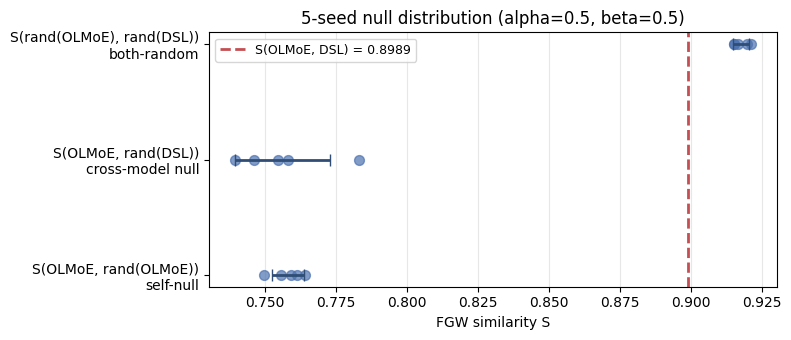

In [4]:
# === Multi-seed null distribution ===
#
# Run randomise_dag with N_SEEDS independent permutations and collect the three
# null similarities each time. Gives a mean +/- std band so we can judge
# whether the +0.15 gap (S_real vs cross-null) is robust or noisy.
# n_init=10 in fgw_similarity already pins each per-seed FGW number tightly;
# the spread here is over the SHUFFLE seed, not the FGW solver.

N_SEEDS = 5  # bump to 10 if you want tighter bands; cost ~linear

results = {"self_null": [], "cross_null": [], "both_null": []}

print(f"--- Multi-seed null sweep (N_SEEDS={N_SEEDS}, alpha={ALPHA}, beta={BETA}) ---")
for seed in range(N_SEEDS):
    dag_o_r = randomise_dag(dags[("olmoe", DATASET)],            rng_seed=seed)
    dag_d_r = randomise_dag(dags[("deepseek-v2-lite", DATASET)], rng_seed=seed + 1000)
    triple_o_r = build_triple(dag_o_r, classifications["olmoe"],
                              beta=BETA, edge_threshold=0.0)
    triple_d_r = build_triple(dag_d_r, classifications["deepseek-v2-lite"],
                              beta=BETA, edge_threshold=0.0)

    s_self,  _ = fgw_similarity(triples["olmoe"], triple_o_r,
                                alpha=ALPHA, n_init=10)
    s_cross, _ = fgw_similarity(triples["olmoe"], triple_d_r,
                                alpha=ALPHA, n_init=10)
    s_both,  _ = fgw_similarity(triple_o_r, triple_d_r,
                                alpha=ALPHA, n_init=10)

    results["self_null"].append(s_self)
    results["cross_null"].append(s_cross)
    results["both_null"].append(s_both)
    print(f"  seed={seed:2d}  self={s_self:.4f}  cross={s_cross:.4f}  both={s_both:.4f}",
          flush=True)

# --- Summary ---
labels_short = {
    "self_null":  "S(OLMoE,        rand(OLMoE))",
    "cross_null": "S(OLMoE,        rand(DSL))  ",
    "both_null":  "S(rand(OLMoE),  rand(DSL))  ",
}
print(f"\n--- Summary ({N_SEEDS} seeds) ---")
print(f"  S(OLMoE, DSL)                 = {S_real:.4f}    (deterministic)")
for k, label in labels_short.items():
    vals = np.array(results[k])
    mean = vals.mean()
    std  = vals.std(ddof=1)
    print(f"  {label} = {mean:.4f} +/- {std:.4f}    "
          f"(min={vals.min():.4f}, max={vals.max():.4f})")

cross_vals = np.array(results["cross_null"])
gap  = S_real - cross_vals.mean()
zval = gap / cross_vals.std(ddof=1)
print(f"\n  Gap (S_real - mean cross-null) = {gap:+.4f}")
print(f"  z (in cross-null std units)    = {zval:+.2f}")

# --- Strip plot: per-seed nulls vs S_real ---
fig, ax = plt.subplots(figsize=(8, 3.5))
labels_plot = ["S(OLMoE, rand(OLMoE))\nself-null",
               "S(OLMoE, rand(DSL))\ncross-model null",
               "S(rand(OLMoE), rand(DSL))\nboth-random"]
keys_plot = ["self_null", "cross_null", "both_null"]
for i, (lbl, k) in enumerate(zip(labels_plot, keys_plot)):
    vals = results[k]
    ax.scatter(vals, [i] * len(vals), color="#4C72B0", s=50, alpha=0.7, zorder=3)
    m, s = np.mean(vals), np.std(vals, ddof=1)
    ax.errorbar([m], [i], xerr=[[s]], color="#2F4D75", capsize=4, linewidth=2, zorder=4)
ax.axvline(S_real, color="#C44E52", linestyle="--", linewidth=2,
           label=f"S(OLMoE, DSL) = {S_real:.4f}")
ax.set_yticks(range(3))
ax.set_yticklabels(labels_plot)
ax.set_xlabel("FGW similarity S")
ax.set_title(f"{N_SEEDS}-seed null distribution (alpha={ALPHA}, beta={BETA})")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


Pre-building 5 randomised DSL triples ...

--- alpha sweep (beta=0.5, N_SEEDS=5) ---
  alpha    S_real     S_null (mean +/- std)       gap       z
   0.00    0.8252        0.5846 +/- 0.0259   +0.2406   +9.29
   0.25    0.8611        0.6648 +/- 0.0220   +0.1963   +8.92
   0.50    0.8989        0.7564 +/- 0.0167   +0.1425   +8.56
   0.75    0.9404        0.8625 +/- 0.0095   +0.0778   +8.20
   1.00    0.9889        0.9882 +/- 0.0002   +0.0007   +4.06


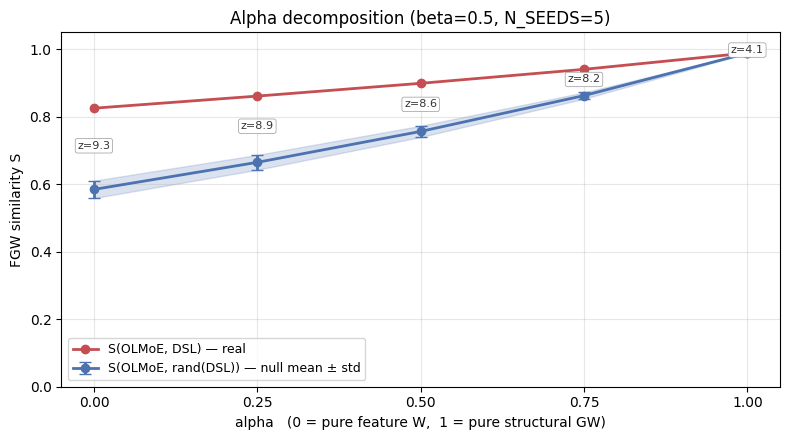

In [5]:
# === Alpha decomposition: where does the +0.14 signal live? ===
#
# Run the same OLMoE vs DSL comparison (real + one-side-random nulls) across
# alpha in {0.0, 0.25, 0.5, 0.75, 1.0}.
#   alpha = 0 -> pure Wasserstein on features F (depth + out/in/load + class).
#   alpha = 1 -> pure Gromov-Wasserstein on structural cost C.
# The Platonic hypothesis predicts a *feature-side* signal (semantic
# specialisation across architectures), so a clear alpha=0 gap = the strongest
# Platonic evidence.
#
# Caveat: beta is held at its default 0.5, so C still mixes depth (preserved
# under randomisation) with path distance (destroyed). The alpha = 1 endpoint
# captures partial-structural signal, not pure path signal -- a separate beta
# sweep can pin that down later.

ALPHAS_SWEEP   = [0.0, 0.25, 0.5, 0.75, 1.0]
N_SEEDS_DECOMP = 5

# Build the randomised DSL triples ONCE; they don't depend on alpha.
print(f"Pre-building {N_SEEDS_DECOMP} randomised DSL triples ...", flush=True)
dsl_rand_triples = []
for seed in range(N_SEEDS_DECOMP):
    dag_d_r = randomise_dag(dags[("deepseek-v2-lite", DATASET)], rng_seed=seed + 1000)
    dsl_rand_triples.append(
        build_triple(dag_d_r, classifications["deepseek-v2-lite"],
                     beta=BETA, edge_threshold=0.0)
    )

# Sweep alpha
print(f"\n--- alpha sweep (beta={BETA}, N_SEEDS={N_SEEDS_DECOMP}) ---")
print(f"  {'alpha':>5s}  {'S_real':>8s}  {'S_null (mean +/- std)':>24s}  {'gap':>8s}  {'z':>6s}")
results_alpha = {}
for alpha in ALPHAS_SWEEP:
    s_real, _ = fgw_similarity(triples["olmoe"], triples["deepseek-v2-lite"],
                               alpha=alpha, n_init=10)
    nulls = []
    for t_d_rand in dsl_rand_triples:
        s, _ = fgw_similarity(triples["olmoe"], t_d_rand,
                              alpha=alpha, n_init=10)
        nulls.append(s)
    nulls = np.array(nulls)
    null_mean = nulls.mean()
    null_std  = nulls.std(ddof=1)
    gap = s_real - null_mean
    z = gap / null_std if null_std > 1e-12 else float("inf")
    results_alpha[alpha] = {"real": s_real, "nulls": nulls,
                            "mean": null_mean, "std": null_std,
                            "gap": gap, "z": z}
    print(f"  {alpha:>5.2f}  {s_real:>8.4f}  {null_mean:>12.4f} +/- {null_std:.4f}  "
          f"{gap:>+8.4f}  {z:>+6.2f}", flush=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.array(ALPHAS_SWEEP)
s_reals    = np.array([results_alpha[a]["real"] for a in ALPHAS_SWEEP])
null_means = np.array([results_alpha[a]["mean"] for a in ALPHAS_SWEEP])
null_stds  = np.array([results_alpha[a]["std"]  for a in ALPHAS_SWEEP])

ax.plot(xs, s_reals, marker="o", color="#C44E52", linewidth=2,
        label="S(OLMoE, DSL) — real")
ax.fill_between(xs, null_means - null_stds, null_means + null_stds,
                alpha=0.2, color="#4C72B0")
ax.errorbar(xs, null_means, yerr=null_stds, marker="o", color="#4C72B0",
            linewidth=2, capsize=4, label="S(OLMoE, rand(DSL)) — null mean ± std")
for x, r, nm, ns in zip(xs, s_reals, null_means, null_stds):
    z = (r - nm) / ns if ns > 1e-12 else float("inf")
    ax.annotate(f"z={z:.1f}", xy=(x, (r + nm) / 2),
                fontsize=8, ha="center", color="#333",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#999", lw=0.5))

ax.set_xlabel("alpha   (0 = pure feature W,  1 = pure structural GW)")
ax.set_ylabel("FGW similarity S")
ax.set_title(f"Alpha decomposition (beta={BETA}, N_SEEDS={N_SEEDS_DECOMP})")
ax.set_xticks(xs)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# === Transport plan inspection at alpha=0 ===
#
# Look at WHICH OLMoE experts get matched to WHICH DSL experts under the
# feature-only transport plan. If the +0.241 gap is genuine super-expert
# alignment, the matches should:
#   (a) sit at similar relative depths,
#   (b) pair high-out-strength experts with each other,
#   (c) have similar class-histogram profiles.
# T[i, k] / mass[i] = fraction of expert i's mass routed to expert k.
# argmax_k T[i, :] = primary match.

# 1. alpha=0 transport plan (fgw_similarity returns (S, T)).
_, T_alpha0 = fgw_similarity(triples["olmoe"], triples["deepseek-v2-lite"],
                             alpha=0.0, n_init=10)
print(f"Transport plan: {T_alpha0.shape}")

# 2. Helpers.
moe_layers_o = dags[("olmoe", DATASET)]["moe_layers"]
moe_layers_d = dags[("deepseek-v2-lite", DATASET)]["moe_layers"]
N_o = triples["olmoe"][3]["N"]
N_d = triples["deepseek-v2-lite"][3]["N"]

def expert_str(triple, vertex_idx, model_N, moe_layers):
    """One-line summary: 'M{layer}E{expert} d={depth:.2f} out={out:.2f} cls=[top-2]'."""
    f = triple[1][int(vertex_idx)]
    l = int(vertex_idx) // model_N
    n = int(vertex_idx) % model_N
    cls_hist = f[4:9]
    parts = sorted(zip(TOKEN_CLASSES, cls_hist), key=lambda x: -x[1])[:2]
    cls_top = ",".join(f"{nm[:4]}={fr:.2f}" for nm, fr in parts if fr > 0.05)
    return f"M{moe_layers[l]:>2d}E{n:>2d} d={f[0]:.2f} out={f[1]:.2f} cls=[{cls_top}]"


# 3. Top OLMoE super-experts -> their DSL matches.
TOP_K = 15
out_o = triples["olmoe"][1][:, 1]
mass_o = triples["olmoe"][2]
order_o = np.argsort(out_o)[::-1][:TOP_K]

print(f"\n=== Top-{TOP_K} OLMoE super-experts -> matched DSL expert (alpha=0) ===\n")
for rnk, oi in enumerate(order_o, 1):
    di = int(np.argmax(T_alpha0[oi]))
    T_frac = float(T_alpha0[oi, di] / mass_o[oi]) if mass_o[oi] > 0 else 0.0
    o_str = expert_str(triples["olmoe"], int(oi), N_o, moe_layers_o)
    d_str = expert_str(triples["deepseek-v2-lite"], di, N_d, moe_layers_d)
    print(f"  #{rnk:>2d}  {o_str:<46s}  ->  {d_str:<46s}  ({T_frac:5.1%})")

# 4. Reverse direction: top DSL super-experts -> OLMoE matches.
out_d = triples["deepseek-v2-lite"][1][:, 1]
mass_d = triples["deepseek-v2-lite"][2]
order_d = np.argsort(out_d)[::-1][:TOP_K]

print(f"\n=== Top-{TOP_K} DSL super-experts -> matched OLMoE expert ===\n")
for rnk, di in enumerate(order_d, 1):
    oi = int(np.argmax(T_alpha0[:, di]))
    T_frac = float(T_alpha0[oi, di] / mass_d[di]) if mass_d[di] > 0 else 0.0
    d_str = expert_str(triples["deepseek-v2-lite"], int(di), N_d, moe_layers_d)
    o_str = expert_str(triples["olmoe"], oi, N_o, moe_layers_o)
    print(f"  #{rnk:>2d}  {d_str:<46s}  ->  {o_str:<46s}  ({T_frac:5.1%})")


# 5. Aggregate match quality across the top-K super-experts.
def aggregate(order_src, T_mtx, src_tr, dst_tr, axis):
    dep_diffs, cls_cos = [], []
    for i in order_src:
        j = int(np.argmax(T_mtx[i] if axis == 0 else T_mtx[:, i]))
        f_s = src_tr[1][int(i)]; f_d = dst_tr[1][j]
        dep_diffs.append(abs(f_s[0] - f_d[0]))
        cs, cd = f_s[4:9], f_d[4:9]
        denom = np.linalg.norm(cs) * np.linalg.norm(cd)
        cls_cos.append(float(np.dot(cs, cd) / denom) if denom > 0 else 0.0)
    return np.mean(dep_diffs), np.mean(cls_cos)


dep_OD, cls_OD = aggregate(order_o, T_alpha0,
                           triples["olmoe"], triples["deepseek-v2-lite"], axis=0)
dep_DO, cls_DO = aggregate(order_d, T_alpha0,
                           triples["deepseek-v2-lite"], triples["olmoe"], axis=1)

print(f"\n=== Aggregate match quality (top-{TOP_K} super-experts each direction) ===")
print(f"  OLMoE -> DSL :  mean |Δdepth| = {dep_OD:.3f}    mean class-cosine = {cls_OD:.3f}")
print(f"  DSL   -> OLMoE: mean |Δdepth| = {dep_DO:.3f}    mean class-cosine = {cls_DO:.3f}")
print(f"\n  Reference scales: |Δdepth| in [0, 1]; class-cosine in [0, 1].")
print(f"  Random matches would give E[|Δdepth|] ≈ 0.33 and class-cosine ≈ 0.85")
print(f"  (the class-cosine baseline is high because content+functional dominate everywhere).")


Transport plan: (1024, 1664)

=== Top-15 OLMoE super-experts -> matched DSL expert (alpha=0) ===

  # 1  M 1E 9 d=0.07 out=1.00 cls=[cont=1.00]          ->  M 3E54 d=0.08 out=1.00 cls=[spec=1.00]          (54.4%)
  # 2  M 4E14 d=0.27 out=0.53 cls=[func=1.00]          ->  M 4E38 d=0.12 out=0.42 cls=[func=0.91,cont=0.08]  (43.4%)
  # 3  M 2E30 d=0.13 out=0.37 cls=[cont=0.74,func=0.25]  ->  M 6E 8 d=0.20 out=0.14 cls=[cont=0.59,func=0.40]  (21.3%)
  # 4  M 0E 6 d=0.00 out=0.29 cls=[func=0.52,cont=0.32]  ->  M 8E33 d=0.28 out=0.13 cls=[func=0.57,cont=0.40]  (23.7%)
  # 5  M 0E38 d=0.00 out=0.23 cls=[func=1.00]          ->  M 1E52 d=0.00 out=0.13 cls=[func=0.92]          (30.0%)
  # 6  M 0E41 d=0.00 out=0.23 cls=[cont=0.99]          ->  M 7E53 d=0.24 out=0.12 cls=[cont=0.89,func=0.09]  (28.8%)
  # 7  M 0E36 d=0.00 out=0.21 cls=[cont=0.70,func=0.12]  ->  M 5E59 d=0.16 out=0.12 cls=[nume=0.56,cont=0.26]  (32.3%)
  # 8  M 0E57 d=0.00 out=0.20 cls=[cont=0.91,func=0.07]  ->  M 3E24 d=0.08 out=0.

In [7]:
# === BOS-asymmetry deep-dive: mask DSL's special-class super-experts ===
#
# Hypothesis: the +0.241 alpha=0 gap is partially obscured by a marginal-
# constraint artifact -- DSL's BOS/special-class super-experts (~3% of tokens,
# no OLMoE counterpart since OLMoE doesn't auto-prepend BOS) get force-matched
# to OLMoE's top content experts. Drop DSL vertices with class_hist[special] > 0.5
# and recompute everything at alpha=0.
#
# Note: the class histogram is the same in real and randomised DSL (it derives
# from top_token / top_pos, not from W), so the same mask applies to both --
# the null baseline can be recomputed cleanly.

SPECIAL_IDX = TOKEN_CLASSES.index("special")
MASK_THRESH = 0.5


def mask_triple_by_class(triple, class_idx, threshold):
    """Drop vertices where class_hist[class_idx] > threshold. Returns
    (C', F', mass', meta'). meta' carries `keep_idx` so masked-triple
    vertex IDs map back to the original."""
    C, F, mass, meta = triple
    keep = F[:, 4 + class_idx] <= threshold
    keep_idx = np.where(keep)[0]
    C_m    = C[np.ix_(keep_idx, keep_idx)]
    F_m    = F[keep_idx]
    mass_m = mass[keep_idx]; mass_m = mass_m / mass_m.sum()
    meta_m = dict(meta); meta_m["n_verts"] = len(keep_idx); meta_m["keep_idx"] = keep_idx
    return (C_m, F_m, mass_m, meta_m)


# --- Step 1: mask DSL ---
triple_d_msk = mask_triple_by_class(triples["deepseek-v2-lite"], SPECIAL_IDX, MASK_THRESH)
n_before = triples["deepseek-v2-lite"][3]["n_verts"]
n_kept   = triple_d_msk[3]["n_verts"]
n_dropped = n_before - n_kept
print(f"=== Step 1: DSL special-class mask (class='special', threshold={MASK_THRESH}) ===")
print(f"  dropped {n_dropped}/{n_before} vertices ({100*n_dropped/n_before:.1f}%);  kept {n_kept}")

F_dsl = triples["deepseek-v2-lite"][1]
dropped_idx = np.where(F_dsl[:, 4 + SPECIAL_IDX] > MASK_THRESH)[0]
dropped_by_out = dropped_idx[np.argsort(F_dsl[dropped_idx, 1])[::-1]]
print(f"\n  Top dropped DSL vertices (by out-strength):")
for di in dropped_by_out[:10]:
    print(f"    {expert_str(triples['deepseek-v2-lite'], int(di), N_d, moe_layers_d)}")

# --- Step 2: similarity + null at alpha=0, masked vs unmasked ---
print(f"\n=== Step 2: alpha=0 similarity, masked vs unmasked ===")
S_real_unm = results_alpha[0.0]["real"]
S_real_msk, T_masked = fgw_similarity(triples["olmoe"], triple_d_msk,
                                      alpha=0.0, n_init=10)
print(f"  S(OLMoE, DSL)         unmasked = {S_real_unm:.4f}")
print(f"  S(OLMoE, DSL_masked)  masked   = {S_real_msk:.4f}")

print(f"\n  Computing cross-model null on masked DSL ({N_SEEDS_DECOMP} seeds) ...", flush=True)
masked_nulls = []
for seed in range(N_SEEDS_DECOMP):
    dag_d_r = randomise_dag(dags[("deepseek-v2-lite", DATASET)], rng_seed=seed + 1000)
    t_d_r = build_triple(dag_d_r, classifications["deepseek-v2-lite"],
                         beta=BETA, edge_threshold=0.0)
    t_d_r_msk = mask_triple_by_class(t_d_r, SPECIAL_IDX, MASK_THRESH)
    s, _ = fgw_similarity(triples["olmoe"], t_d_r_msk, alpha=0.0, n_init=10)
    masked_nulls.append(s)
    print(f"    seed={seed:2d}  S_null_masked = {s:.4f}", flush=True)
masked_nulls = np.array(masked_nulls)
nm_mean, nm_std = masked_nulls.mean(), masked_nulls.std(ddof=1)
gap_msk = S_real_msk - nm_mean
z_msk = gap_msk / nm_std if nm_std > 1e-12 else float("inf")

print(f"\n  null (unmasked) = {results_alpha[0.0]['mean']:.4f} +/- {results_alpha[0.0]['std']:.4f}"
      f"    gap=+{results_alpha[0.0]['gap']:.4f}    z={results_alpha[0.0]['z']:+.2f}")
print(f"  null (masked)   = {nm_mean:.4f} +/- {nm_std:.4f}"
      f"    gap={gap_msk:+.4f}    z={z_msk:+.2f}")

# --- Step 3: top-15 inspection on the masked plan ---
TOP_K = 15
mass_o = triples["olmoe"][2]
out_o  = triples["olmoe"][1][:, 1]
order_o = np.argsort(out_o)[::-1][:TOP_K]
keep_idx_d = triple_d_msk[3]["keep_idx"]

print(f"\n=== Step 3: Top-{TOP_K} OLMoE super-experts -> masked-DSL matches ===\n")
dep_OD_m, cls_OD_m = [], []
for rnk, oi in enumerate(order_o, 1):
    di_m = int(np.argmax(T_masked[oi]))
    di_o = int(keep_idx_d[di_m])
    T_frac = float(T_masked[oi, di_m] / mass_o[oi]) if mass_o[oi] > 0 else 0.0
    o_str = expert_str(triples["olmoe"], int(oi), N_o, moe_layers_o)
    d_str = expert_str(triples["deepseek-v2-lite"], di_o, N_d, moe_layers_d)
    print(f"  #{rnk:>2d}  {o_str:<46s}  ->  {d_str:<46s}  ({T_frac:5.1%})")

    f_s = triples["olmoe"][1][int(oi)]
    f_d = triples["deepseek-v2-lite"][1][di_o]
    dep_OD_m.append(abs(f_s[0] - f_d[0]))
    cs, cd = f_s[4:9], f_d[4:9]
    denom = np.linalg.norm(cs) * np.linalg.norm(cd)
    cls_OD_m.append(float(np.dot(cs, cd) / denom) if denom > 0 else 0.0)

# --- Step 4: before/after summary ---
print(f"\n=== Step 4: aggregate quality summary (top-{TOP_K}, OLMoE -> DSL) ===")
print(f"  unmasked:  mean |Δdepth| = {dep_OD:.3f}    mean class-cosine = {cls_OD:.3f}    gap = +{results_alpha[0.0]['gap']:.4f}  (z={results_alpha[0.0]['z']:.2f})")
print(f"  masked:    mean |Δdepth| = {np.mean(dep_OD_m):.3f}    mean class-cosine = {np.mean(cls_OD_m):.3f}    gap = {gap_msk:+.4f}  (z={z_msk:.2f})")


=== Step 1: DSL special-class mask (class='special', threshold=0.5) ===
  dropped 25/1664 vertices (1.5%);  kept 1639

  Top dropped DSL vertices (by out-strength):
    M 3E54 d=0.08 out=1.00 cls=[spec=1.00]
    M 2E 3 d=0.04 out=0.25 cls=[spec=1.00]
    M25E11 d=0.96 out=0.10 cls=[spec=1.00]
    M 4E21 d=0.12 out=0.08 cls=[spec=1.00]
    M24E63 d=0.92 out=0.07 cls=[spec=1.00]
    M 5E52 d=0.16 out=0.06 cls=[spec=1.00]
    M11E18 d=0.40 out=0.06 cls=[spec=1.00]
    M 8E54 d=0.28 out=0.05 cls=[spec=1.00]
    M10E13 d=0.36 out=0.05 cls=[spec=0.98]
    M13E47 d=0.48 out=0.05 cls=[spec=1.00]

=== Step 2: alpha=0 similarity, masked vs unmasked ===
  S(OLMoE, DSL)         unmasked = 0.8252
  S(OLMoE, DSL_masked)  masked   = 0.8452

  Computing cross-model null on masked DSL (5 seeds) ...
    seed= 0  S_null_masked = 0.5805
    seed= 1  S_null_masked = 0.5938
    seed= 2  S_null_masked = 0.5989
    seed= 3  S_null_masked = 0.6390
    seed= 4  S_null_masked = 0.5703

  null (unmasked) = 0.5846

## §4. All-pairs and cross-task analyses

Scaling the validated pipeline to multiple models and tasks. Cells in this section
build on §3's `classifications`, `triples`, `mask_triple_by_class`, and `randomise_dag`.

*Depends on §0 and §3.*

In [ ]:
# === All-pairs FGW similarity heatmap (alpha=0, BOS-masked) ===
#
# 8 MoE models on C4: pairwise S_alpha=0 with each model's special-class
# vertices masked (threshold=0.5).
# beta=1 skips the shortest-path computation in build_triple (irrelevant at
# alpha=0 anyway) -- this is a big speedup for the large Qwen / DeepSeek-V2
# graphs (12k / 9k vertices).
#
# Model order groups families adjacently so within-family blocks pop visually:
#   Mixtral 7B / 22B  |  DSL / DS-V2  |  Qwen 30B / 235B  |  OLMoE / Phi-3.5

import time

ALPHA_HM   = 0.0
BETA_FAST  = 1.0   # alpha=0 doesn't use C, so skip shortest-path

MODEL_IDS_FULL = {
    "olmoe":            "allenai/OLMoE-1B-7B-0924",
    "deepseek-v2":      "deepseek-ai/DeepSeek-V2",
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite",
    "mixtral-8x7b":     "mistralai/Mixtral-8x7B-v0.1",
    "mixtral-8x22b":    "mistralai/Mixtral-8x22B-v0.1",
    "qwen3-30b-a3b":    "Qwen/Qwen3-30B-A3B",
    "qwen3-235b-a22b":  "Qwen/Qwen3-235B-A22B",
    "phi-3.5-moe":      "microsoft/Phi-3.5-MoE-instruct",
}

HM_MODELS = [
    "mixtral-8x7b", "mixtral-8x22b",      # Mixtral family
    "deepseek-v2-lite", "deepseek-v2",    # DeepSeek family
    "qwen3-30b-a3b", "qwen3-235b-a22b",   # Qwen family
    "olmoe", "phi-3.5-moe",               # singletons
]

# --- Step 1: per-model classification (cached on disk) ---
print("=== Step 1: per-model classification (cached) ===", flush=True)
classifications_all = {}
for m in HM_MODELS:
    cache_path = os.path.join(CLASS_CACHE_DIR, f"classify_{m}_{DATASET}.pkl")
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            classifications_all[m] = pickle.load(f)
        src = "cached"
    else:
        tok = AutoTokenizer.from_pretrained(MODEL_IDS_FULL[m],
                                            trust_remote_code=True, use_fast=True)
        print(f"  classifying {m} ...", flush=True)
        classifications_all[m] = build_token_classification(
            prompts, tok, max_length=MAX_TOKENS, verbose=False)
        with open(cache_path, "wb") as f:
            pickle.dump(classifications_all[m], f)
        src = "built"
    counts = np.bincount(list(classifications_all[m].values()),
                         minlength=len(TOKEN_CLASSES))
    shares = counts / counts.sum()
    pretty = " ".join(f"{c[:4]}={100*s:>4.1f}%" for c, s in zip(TOKEN_CLASSES, shares))
    print(f"  {m:<18s} ({src:>6s})  {pretty}", flush=True)

# --- Step 2: per-model masked triple ---
print(f"\n=== Step 2: per-model triples, beta={BETA_FAST}, mask special >{MASK_THRESH} ===", flush=True)
triples_all = {}
for m in HM_MODELS:
    t = build_triple(dags[(m, DATASET)], classifications_all[m],
                     beta=BETA_FAST, edge_threshold=0.0)
    t_msk = mask_triple_by_class(t, SPECIAL_IDX, MASK_THRESH)
    n_drop = t[3]["n_verts"] - t_msk[3]["n_verts"]
    print(f"  {m:<18s}  n_verts={t[3]['n_verts']:>5d}  "
          f"dropped={n_drop:>3d}  kept={t_msk[3]['n_verts']:>5d}", flush=True)
    triples_all[m] = t_msk

# --- Step 3: pairwise FGW (upper triangle; mirror to full matrix) ---
n_m = len(HM_MODELS)
S_mat = np.eye(n_m)
print(f"\n=== Step 3: pairwise S_alpha=0 ({n_m*(n_m-1)//2} cross-model pairs, n_init=5) ===", flush=True)
total_t0 = time.time()
for i in range(n_m):
    for j in range(i + 1, n_m):
        m_i, m_j = HM_MODELS[i], HM_MODELS[j]
        t0 = time.time()
        S, _ = fgw_similarity(triples_all[m_i], triples_all[m_j],
                              alpha=ALPHA_HM, n_init=5)
        S_mat[i, j] = S
        S_mat[j, i] = S
        dt = time.time() - t0
        print(f"  S({m_i:<18s}, {m_j:<18s}) = {S:.4f}    [{dt:.1f}s]", flush=True)
print(f"\nTotal heatmap compute: {(time.time() - total_t0)/60:.1f} min")

# --- Step 4: render heatmap ---
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(S_mat, cmap="viridis", vmin=0.0, vmax=1.0, origin="upper")
ax.set_xticks(range(n_m)); ax.set_yticks(range(n_m))
ax.set_xticklabels(HM_MODELS, rotation=45, ha="right")
ax.set_yticklabels(HM_MODELS)
for i in range(n_m):
    for j in range(n_m):
        ax.text(j, i, f"{S_mat[i, j]:.3f}", ha="center", va="center",
                color="white" if S_mat[i, j] < 0.55 else "black", fontsize=9)

# Highlight within-family blocks with thin red boxes.
family_pairs = [(0, 1), (2, 3), (4, 5)]  # Mixtral, DSL/DSv2, Qwen
for (i, j) in family_pairs:
    for ii, jj in [(i, j), (j, i)]:
        ax.add_patch(plt.Rectangle((jj - 0.5, ii - 0.5), 1, 1,
                                    fill=False, edgecolor="red", lw=2))

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="S(alpha=0)")
ax.set_title(f"All-pairs FGW similarity at alpha={ALPHA_HM}, c4\n"
             f"(special-class masked, beta={BETA_FAST}; red boxes = within-family)")
plt.tight_layout()
plt.show()

# --- Step 5: ranked numeric summary ---
print(f"\n=== Cross-model S_alpha=0 pairs (sorted descending) ===")
pairs = [(i, j, S_mat[i, j]) for i in range(n_m) for j in range(i + 1, n_m)]
pairs.sort(key=lambda x: -x[2])
for i, j, s in pairs:
    in_fam = "  [SAME FAMILY]" if (i, j) in family_pairs or (j, i) in family_pairs else ""
    print(f"  S({HM_MODELS[i]:<18s}, {HM_MODELS[j]:<18s}) = {s:.4f}{in_fam}")


In [ ]:
# === Cross-task FGW (OLMoE + DSL on c4 / math / code) ===
#
# WM  = within-model cross-task (does the same model route similarly across tasks?)
# CMS = cross-model same-task (Platonic baseline per task)
# CMD = cross-model different-task
# Headline diagnostic: CMS - CMD.
#   positive  => per-task Platonic alignment (models converge MORE same-task)
#   near zero => alignment is task-invariant (routing by token kind, not task context)
import time
from dataset.math_dataset import open_r1_math_dataset_helper
from dataset.code_dataset import code_dataset_helper

ALPHA_HM   = 0.0
BETA_FAST  = 1.0   # alpha=0 doesn't use C, so skip shortest-path

MODEL_IDS_FULL = {
    "olmoe":            "allenai/OLMoE-1B-7B-0924",
    "deepseek-v2":      "deepseek-ai/DeepSeek-V2",
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite",
    "mixtral-8x7b":     "mistralai/Mixtral-8x7B-v0.1",
    "mixtral-8x22b":    "mistralai/Mixtral-8x22B-v0.1",
    "qwen3-30b-a3b":    "Qwen/Qwen3-30B-A3B",
    "qwen3-235b-a22b":  "Qwen/Qwen3-235B-A22B",
    "phi-3.5-moe":      "microsoft/Phi-3.5-MoE-instruct",
}

HM_MODELS = [
    "mixtral-8x7b", "mixtral-8x22b",      # Mixtral family
    "deepseek-v2-lite", "deepseek-v2",    # DeepSeek family
    "qwen3-30b-a3b", "qwen3-235b-a22b",   # Qwen family
    "olmoe", "phi-3.5-moe",               # singletons
]

CT_MODELS = ["olmoe", "deepseek-v2-lite"]
CT_TASKS  = ["c4", "math", "code"]

DATASET_LOADERS = {
    "c4":   c4_dataset_helper,
    "math": open_r1_math_dataset_helper,
    "code": code_dataset_helper,
}

# --- Step 1: per-task prompts ---
print("=== Step 1: load per-task prompts ===", flush=True)
prompts_by_task = {}
for t in CT_TASKS:
    prompts_by_task[t] = DATASET_LOADERS[t](dataset_len=N_PROMPTS, min_words=MAX_TOKENS)
    print(f"  {t:<5s}: {len(prompts_by_task[t])} prompts")

# --- Step 2: load DAGs for (model, task) tuples not already in `dags` ---
print(f"\n=== Step 2: load DAGs ===", flush=True)
for m in CT_MODELS:
    for t in CT_TASKS:
        if (m, t) not in dags:
            path = os.path.join(config["result_path"], f"circuits/dag_{m}_{t}.pt")
            dags[(m, t)] = torch.load(path, map_location="cpu")
            print(f"  loaded {m}/{t}")
        else:
            print(f"  cached  {m}/{t}")

# --- Step 3: per-(model, task) classification ---
print(f"\n=== Step 3: classifications ===", flush=True)
ct_class = {}
for m in CT_MODELS:
    tok = AutoTokenizer.from_pretrained(MODEL_IDS_FULL[m],
                                        trust_remote_code=True, use_fast=True)
    for t in CT_TASKS:
        cache_path = os.path.join(CLASS_CACHE_DIR, f"classify_{m}_{t}.pkl")
        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                ct_class[(m, t)] = pickle.load(f)
            src = "cached"
        else:
            print(f"  classifying {m}/{t} ...", flush=True)
            ct_class[(m, t)] = build_token_classification(
                prompts_by_task[t], tok, max_length=MAX_TOKENS, verbose=False)
            with open(cache_path, "wb") as f:
                pickle.dump(ct_class[(m, t)], f)
            src = "built"
        counts = np.bincount(list(ct_class[(m, t)].values()), minlength=len(TOKEN_CLASSES))
        shares = counts / counts.sum()
        pretty = " ".join(f"{c[:4]}={100*s:>4.1f}%" for c, s in zip(TOKEN_CLASSES, shares))
        print(f"  {m}/{t:<5s} ({src:>6s})  {pretty}")

# --- Step 4: build masked triples ---
print(f"\n=== Step 4: triples (beta=1, mask special >{MASK_THRESH}) ===", flush=True)
ct_triples = {}
for m in CT_MODELS:
    for t in CT_TASKS:
        tr = build_triple(dags[(m, t)], ct_class[(m, t)],
                          beta=1.0, edge_threshold=0.0)
        tr_msk = mask_triple_by_class(tr, SPECIAL_IDX, MASK_THRESH)
        n_drop = tr[3]["n_verts"] - tr_msk[3]["n_verts"]
        print(f"  {m}/{t:<5s}  n_verts={tr[3]['n_verts']:>5d}  "
              f"dropped={n_drop:>3d}  kept={tr_msk[3]['n_verts']:>5d}")
        ct_triples[(m, t)] = tr_msk

# --- Step 5: pairwise FGW at alpha=0 ---
keys = [(m, t) for m in CT_MODELS for t in CT_TASKS]
n_k = len(keys)
S_ct = np.eye(n_k)
print(f"\n=== Step 5: pairwise FGW (alpha=0, {n_k*(n_k-1)//2} pairs) ===", flush=True)
t_start = time.time()
for i in range(n_k):
    for j in range(i + 1, n_k):
        S, _ = fgw_similarity(ct_triples[keys[i]], ct_triples[keys[j]],
                              alpha=0.0, n_init=5)
        S_ct[i, j] = S
        S_ct[j, i] = S
        print(f"  S({keys[i][0]}/{keys[i][1]:<5s} <-> {keys[j][0]}/{keys[j][1]:<5s}) = {S:.4f}",
              flush=True)
print(f"\n  total compute: {(time.time() - t_start)/60:.2f} min")

# --- Step 6: heatmap render ---
labels = [f"{m}/{t}" for m, t in keys]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_ct, cmap="viridis", vmin=0.3, vmax=1.0, origin="upper")
ax.set_xticks(range(n_k)); ax.set_yticks(range(n_k))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
for i in range(n_k):
    for j in range(n_k):
        ax.text(j, i, f"{S_ct[i, j]:.3f}", ha="center", va="center",
                color="white" if S_ct[i, j] < 0.6 else "black", fontsize=10)
# Outline within-model 3x3 blocks (red).
ax.add_patch(plt.Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor="red", lw=2.5))
ax.add_patch(plt.Rectangle((2.5, 2.5), 3, 3, fill=False, edgecolor="red", lw=2.5))
# Outline same-task off-diagonal (blue).
for ti in range(3):
    ax.add_patch(plt.Rectangle((ti + 2.5, ti - 0.5), 1, 1, fill=False, edgecolor="blue", lw=2))
    ax.add_patch(plt.Rectangle((ti - 0.5, ti + 2.5), 1, 1, fill=False, edgecolor="blue", lw=2))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="S(alpha=0)")
ax.set_title("Cross-task FGW (alpha=0, special-class masked)\nred = within-model, blue = cross-model same-task")
plt.tight_layout(); plt.show()

# --- Step 7: block summaries ---
idx_o = [0, 1, 2]
idx_d = [3, 4, 5]

def block_mean(rows, cols, exclude_diag=False):
    vals = [S_ct[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals))

WM_o = block_mean(idx_o, idx_o, exclude_diag=True)
WM_d = block_mean(idx_d, idx_d, exclude_diag=True)

cms_pairs = [(0, 3, "c4"), (1, 4, "math"), (2, 5, "code")]
CMS_each  = [S_ct[i, j] for i, j, _ in cms_pairs]
cmd_pairs = [(i, j) for i in idx_o for j in idx_d if i != j - 3]
CMD_each  = [S_ct[i, j] for i, j in cmd_pairs]

print(f"\n=== Block summaries ===")
print(f"  WM   (within-model cross-task):")
print(f"    OLMoE :  {WM_o:.4f}     [c4↔math={S_ct[0,1]:.3f}  c4↔code={S_ct[0,2]:.3f}  math↔code={S_ct[1,2]:.3f}]")
print(f"    DSL   :  {WM_d:.4f}     [c4↔math={S_ct[3,4]:.3f}  c4↔code={S_ct[3,5]:.3f}  math↔code={S_ct[4,5]:.3f}]")

print(f"\n  CMS  (cross-model same-task):")
for i, j, t in cms_pairs:
    print(f"    {t:<5s}:  S(OLMoE/{t}, DSL/{t}) = {S_ct[i, j]:.4f}")
print(f"    mean CMS = {np.mean(CMS_each):.4f}")

print(f"\n  CMD  (cross-model different-task):")
for i, j in cmd_pairs:
    print(f"    S({keys[i][0]}/{keys[i][1]:<5s} <-> {keys[j][0]}/{keys[j][1]:<5s}) = {S_ct[i, j]:.4f}")
print(f"    mean CMD = {np.mean(CMD_each):.4f}")

cms_minus_cmd = np.mean(CMS_each) - np.mean(CMD_each)
print(f"\n  Headline:  CMS - CMD = {cms_minus_cmd:+.4f}")
print(f"    positive ⇒ per-task Platonic alignment (models converge more on same task)")
print(f"    near 0   ⇒ alignment is task-invariant (routing by token kind, not task)")


=== Step 1: load per-task prompts ===
len of my_c4_dataset 5000
  c4   : 5000 prompts


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

len of my_open_r1_math_dataset 5000
  math : 5000 prompts


Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

len of my_code_dataset 5000
  code : 5000 prompts

=== Step 2: load DAGs ===
  cached  olmoe/c4
  cached  olmoe/math
  cached  olmoe/code
  cached  deepseek-v2-lite/c4
  cached  deepseek-v2-lite/math
  cached  deepseek-v2-lite/code

=== Step 3: classifications ===
  olmoe/c4    (cached)  cont=56.5% func=31.9% punc= 9.0% nume= 2.5% spec= 0.2%
  classifying olmoe/math ...
  olmoe/math  ( built)  cont=47.0% func=25.1% punc=15.3% nume= 9.8% spec= 2.7%
  classifying olmoe/code ...
  olmoe/code  ( built)  cont=53.4% func=23.6% punc=15.4% nume= 3.9% spec= 3.6%
  deepseek-v2-lite/c4    (cached)  cont=51.6% func=32.5% punc= 8.6% nume= 4.0% spec= 3.3%
  classifying deepseek-v2-lite/math ...
  deepseek-v2-lite/math  ( built)  cont=42.9% func=25.4% punc=14.2% nume=11.6% spec= 5.9%
  classifying deepseek-v2-lite/code ...
  deepseek-v2-lite/code  ( built)  cont=48.0% func=23.3% punc=13.4% nume= 7.2% spec= 8.0%

=== Step 4: triples (beta=1, mask special >0.5) ===
  olmoe/c4     n_verts= 1024  dropped

NameError: name 'time' is not defined

In [ ]:
# === Cross-task FGW with class histogram DROPPED from F ===
#
# Slice F to [depth, out, in, load] (4 dims) instead of [depth, out, in, load,
# class_0..class_4] (9 dims). Tests whether the +0.164 CMS-CMD signal is
# intrinsic to routing topology + mass, or driven by task-dependent class
# distribution shifts (math has more numerics, code has more punctuation).
#
# C and mass are unchanged from the masked triples we already built. Only F
# is sliced.

def drop_class_features(triple):
    """Slice F to [depth, out, in, load]; keep C, mass, meta unchanged."""
    C, F, mass, meta = triple
    F_short = F[:, :4]
    meta_new = dict(meta); meta_new["D"] = F_short.shape[1]
    return (C, F_short, mass, meta_new)


ct_triples_noclass = {k: drop_class_features(v) for k, v in ct_triples.items()}

# --- Pairwise FGW at alpha=0 with class-stripped features ---
n_k = len(keys)
S_nc = np.eye(n_k)
print(f"=== Pairwise FGW, class DROPPED (alpha=0, {n_k*(n_k-1)//2} pairs) ===", flush=True)
t_start = time.time()
for i in range(n_k):
    for j in range(i + 1, n_k):
        S, _ = fgw_similarity(ct_triples_noclass[keys[i]],
                              ct_triples_noclass[keys[j]],
                              alpha=0.0, n_init=5)
        S_nc[i, j] = S
        S_nc[j, i] = S
        delta = S - S_ct[i, j]
        print(f"  S({keys[i][0]}/{keys[i][1]:<5s} <-> {keys[j][0]}/{keys[j][1]:<5s}) = {S:.4f}  "
              f"(was {S_ct[i, j]:.4f}, Δ={delta:+.4f})", flush=True)
print(f"\n  total compute: {(time.time() - t_start)/60:.2f} min")

# --- Heatmap render ---
labels = [f"{m}/{t}" for m, t in keys]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_nc, cmap="viridis", vmin=0.3, vmax=1.0, origin="upper")
ax.set_xticks(range(n_k)); ax.set_yticks(range(n_k))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
for i in range(n_k):
    for j in range(n_k):
        ax.text(j, i, f"{S_nc[i, j]:.3f}", ha="center", va="center",
                color="white" if S_nc[i, j] < 0.6 else "black", fontsize=10)
ax.add_patch(plt.Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor="red", lw=2.5))
ax.add_patch(plt.Rectangle((2.5, 2.5), 3, 3, fill=False, edgecolor="red", lw=2.5))
for ti in range(3):
    ax.add_patch(plt.Rectangle((ti + 2.5, ti - 0.5), 1, 1, fill=False, edgecolor="blue", lw=2))
    ax.add_patch(plt.Rectangle((ti - 0.5, ti + 2.5), 1, 1, fill=False, edgecolor="blue", lw=2))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="S(alpha=0, no class)")
ax.set_title("Cross-task FGW (alpha=0, class histogram DROPPED)\nred = within-model, blue = same-task")
plt.tight_layout(); plt.show()

# --- Block summaries (mirror of previous cell) ---
def block_mean_nc(rows, cols, exclude_diag=False):
    vals = [S_nc[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals))

WM_o_nc = block_mean_nc(idx_o, idx_o, exclude_diag=True)
WM_d_nc = block_mean_nc(idx_d, idx_d, exclude_diag=True)
CMS_each_nc = [S_nc[i, j] for i, j, _ in cms_pairs]
CMD_each_nc = [S_nc[i, j] for i, j in cmd_pairs]
cms_nc_mean = np.mean(CMS_each_nc)
cmd_nc_mean = np.mean(CMD_each_nc)
diag_nc = cms_nc_mean - cmd_nc_mean

# --- Side-by-side comparison ---
print(f"\n=== Side-by-side: with class hist vs without ===")
print(f"  {'Metric':<28s}  {'with class':>12s}  {'no class':>12s}  {'Δ':>10s}")
print(f"  " + "-" * 70)
print(f"  {'WM(OLMoE)':<28s}  {WM_o:>12.4f}  {WM_o_nc:>12.4f}  {WM_o_nc - WM_o:>+10.4f}")
print(f"  {'WM(DSL)':<28s}  {WM_d:>12.4f}  {WM_d_nc:>12.4f}  {WM_d_nc - WM_d:>+10.4f}")
print(f"  {'CMS mean':<28s}  {np.mean(CMS_each):>12.4f}  {cms_nc_mean:>12.4f}  {cms_nc_mean - np.mean(CMS_each):>+10.4f}")
print(f"  {'CMD mean':<28s}  {np.mean(CMD_each):>12.4f}  {cmd_nc_mean:>12.4f}  {cmd_nc_mean - np.mean(CMD_each):>+10.4f}")
print(f"  {'CMS - CMD':<28s}  {cms_minus_cmd:>+12.4f}  {diag_nc:>+12.4f}  {diag_nc - cms_minus_cmd:>+10.4f}")
print()
print(f"  Per-task CMS:")
for (i, j, t), s_with, s_no in zip(cms_pairs, CMS_each, CMS_each_nc):
    print(f"    {t:<5s}:  with class = {s_with:.4f}    no class = {s_no:.4f}    Δ = {s_no - s_with:+.4f}")
print()
print(f"  Interpretation:")
print(f"    CMS-CMD similar to before (~+0.16) ⇒ per-task signal intrinsic to routing topology + mass")
print(f"    CMS-CMD shrinks toward 0          ⇒ per-task signal was class-distribution shift")
print(f"    CMS-CMD grows                     ⇒ class hist was actually NOISE; routing is even more per-task aligned")


In [ ]:
# === Scaled cross-task FGW: 5 models × 3 tasks ===
#
# Following the OLMoE/DSL contrast (OLMoE task-adaptive, DSL task-invariant),
# scale up to 5 models to characterise the task-adaptive vs task-invariant
# axis across MoE architectures. Mixtral 7B/22B gives us a within-family
# pair to test whether the trait is family-shared. Phi-3.5-MoE is a 4th
# singleton.
#
# 5 models × 3 tasks = 15 tuples → 105 cross-pairs at alpha=0.
# Class histogram dropped (confirmed irrelevant to CMS-CMD in previous cell).

SCALE_MODELS = ["mixtral-8x7b", "mixtral-8x22b", "olmoe", "deepseek-v2-lite", "phi-3.5-moe"]
SCALE_TASKS  = ["c4", "math", "code"]

# --- Load any missing DAGs ---
print("=== Loading DAGs ===", flush=True)
for m in SCALE_MODELS:
    for t in SCALE_TASKS:
        if (m, t) not in dags:
            path = os.path.join(config["result_path"], f"circuits/dag_{m}_{t}.pt")
            dags[(m, t)] = torch.load(path, map_location="cpu")
            print(f"  loaded {m}/{t}")

# --- Load any missing classifications ---
print(f"\n=== Loading classifications ===", flush=True)
sc_class = {}
for m in SCALE_MODELS:
    tok = None
    for t in SCALE_TASKS:
        cache_path = os.path.join(CLASS_CACHE_DIR, f"classify_{m}_{t}.pkl")
        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                sc_class[(m, t)] = pickle.load(f)
        else:
            if tok is None:
                tok = AutoTokenizer.from_pretrained(MODEL_IDS_FULL[m],
                                                    trust_remote_code=True, use_fast=True)
            print(f"  classifying {m}/{t} ...", flush=True)
            sc_class[(m, t)] = build_token_classification(
                prompts_by_task[t], tok, max_length=MAX_TOKENS, verbose=False)
            with open(cache_path, "wb") as f:
                pickle.dump(sc_class[(m, t)], f)

# --- Build masked, class-dropped triples ---
print(f"\n=== Building triples (beta=1, mask special >{MASK_THRESH}, class dropped) ===", flush=True)
sc_triples = {}
for m in SCALE_MODELS:
    for t in SCALE_TASKS:
        tr = build_triple(dags[(m, t)], sc_class[(m, t)],
                          beta=1.0, edge_threshold=0.0)
        tr_msk = mask_triple_by_class(tr, SPECIAL_IDX, MASK_THRESH)
        sc_triples[(m, t)] = drop_class_features(tr_msk)
        print(f"  {m}/{t:<5s}  n_verts={sc_triples[(m, t)][3]['n_verts']:>5d}")

# --- Pairwise FGW ---
sc_keys = [(m, t) for m in SCALE_MODELS for t in SCALE_TASKS]
n_k = len(sc_keys)
S_sc = np.eye(n_k)
print(f"\n=== Pairwise FGW (alpha=0, {n_k*(n_k-1)//2} cross-pairs) ===", flush=True)
t0 = time.time()
for i in range(n_k):
    for j in range(i + 1, n_k):
        S, _ = fgw_similarity(sc_triples[sc_keys[i]], sc_triples[sc_keys[j]],
                              alpha=0.0, n_init=5)
        S_sc[i, j] = S
        S_sc[j, i] = S
print(f"  total compute: {(time.time() - t0)/60:.2f} min")

# --- Heatmap ---
labels = [f"{m}/{t}" for m, t in sc_keys]
fig, ax = plt.subplots(figsize=(12, 10.5))
im = ax.imshow(S_sc, cmap="viridis", vmin=0.2, vmax=1.0, origin="upper")
ax.set_xticks(range(n_k)); ax.set_yticks(range(n_k))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(n_k):
    for j in range(n_k):
        ax.text(j, i, f"{S_sc[i, j]:.2f}", ha="center", va="center",
                color="white" if S_sc[i, j] < 0.6 else "black", fontsize=7)

# Within-model 3x3 blocks (red).
for mi in range(len(SCALE_MODELS)):
    base = mi * 3
    ax.add_patch(plt.Rectangle((base - 0.5, base - 0.5), 3, 3,
                                fill=False, edgecolor="red", lw=2))

# Same-task off-diagonals (blue) outline.
for ti in range(len(SCALE_TASKS)):
    for mi in range(len(SCALE_MODELS)):
        for mj in range(mi + 1, len(SCALE_MODELS)):
            ri, rj = mi * 3 + ti, mj * 3 + ti
            ax.add_patch(plt.Rectangle((rj - 0.5, ri - 0.5), 1, 1,
                                        fill=False, edgecolor="blue", lw=1.2))
            ax.add_patch(plt.Rectangle((ri - 0.5, rj - 0.5), 1, 1,
                                        fill=False, edgecolor="blue", lw=1.2))

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="S(alpha=0, no class)")
ax.set_title(f"Scaled cross-task FGW: {len(SCALE_MODELS)} models × {len(SCALE_TASKS)} tasks (alpha=0)\n"
             f"red = within-model, blue = cross-model same-task")
plt.tight_layout(); plt.show()

# --- Per-model WM (task stability) ---
print(f"\n=== Per-model WM (within-model cross-task) ===")
print(f"  {'Model':<22s}  {'WM':>7s}  {'c4↔math':>8s}  {'c4↔code':>8s}  {'math↔code':>10s}")
print(f"  " + "-" * 62)
wm_per_model = {}
for mi, m in enumerate(SCALE_MODELS):
    base = mi * 3
    pairs = [S_sc[base, base + 1], S_sc[base, base + 2], S_sc[base + 1, base + 2]]
    wm_per_model[m] = float(np.mean(pairs))
    print(f"  {m:<22s}  {wm_per_model[m]:>7.4f}  {pairs[0]:>8.4f}  {pairs[1]:>8.4f}  {pairs[2]:>10.4f}")

# --- Per-task CMS ---
print(f"\n=== Per-task CMS (cross-model same-task) ===")
print(f"  {'Task':<6s}  {'CMS':>7s}  {'min':>7s}  {'max':>7s}")
print(f"  " + "-" * 36)
cms_per_task = {}
for ti, t in enumerate(SCALE_TASKS):
    same_t = [S_sc[mi*3 + ti, mj*3 + ti]
              for mi in range(len(SCALE_MODELS))
              for mj in range(mi + 1, len(SCALE_MODELS))]
    cms_per_task[t] = float(np.mean(same_t))
    print(f"  {t:<6s}  {cms_per_task[t]:>7.4f}  {min(same_t):>7.4f}  {max(same_t):>7.4f}")

# --- Global CMS vs CMD ---
cms_all, cmd_all = [], []
for mi in range(len(SCALE_MODELS)):
    for mj in range(mi + 1, len(SCALE_MODELS)):
        for ti in range(len(SCALE_TASKS)):
            for tj in range(len(SCALE_TASKS)):
                v = S_sc[mi*3 + ti, mj*3 + tj]
                (cms_all if ti == tj else cmd_all).append(v)
cms_mean = float(np.mean(cms_all))
cmd_mean = float(np.mean(cmd_all))
print(f"\n=== Global CMS vs CMD ===")
print(f"  CMS mean (n={len(cms_all):>3d}): {cms_mean:.4f}")
print(f"  CMD mean (n={len(cmd_all):>3d}): {cmd_mean:.4f}")
print(f"  CMS - CMD              = {cms_mean - cmd_mean:+.4f}")

# --- Per-model task-adaptiveness index ---
# Negative = task-adaptive (WM < CMS_with_others), Positive = task-invariant.
print(f"\n=== Task-adaptiveness index per model:  WM  -  CMS(with others)  ===")
print(f"  {'Model':<22s}  {'WM':>7s}  {'CMS-others':>11s}  {'WM - CMS':>10s}    label")
print(f"  " + "-" * 70)
for mi, m in enumerate(SCALE_MODELS):
    base = mi * 3
    wm = wm_per_model[m]
    cms_others = []
    for mj in range(len(SCALE_MODELS)):
        if mj == mi:
            continue
        for ti in range(len(SCALE_TASKS)):
            cms_others.append(S_sc[base + ti, mj*3 + ti])
    cms_o = float(np.mean(cms_others))
    diff = wm - cms_o
    if diff > 0.05:
        label = "task-invariant"
    elif diff < -0.05:
        label = "task-adaptive"
    else:
        label = "borderline"
    print(f"  {m:<22s}  {wm:>7.4f}  {cms_o:>11.4f}  {diff:>+10.4f}    [{label}]")

# --- Within-family: Mixtral 7B vs 22B ---
i7, i22 = SCALE_MODELS.index("mixtral-8x7b"), SCALE_MODELS.index("mixtral-8x22b")
print(f"\n=== Within-family: Mixtral 7B vs 22B cross-task ===")
for ti, t in enumerate(SCALE_TASKS):
    s = S_sc[i7*3 + ti, i22*3 + ti]
    print(f"  S(7B/{t}, 22B/{t}) = {s:.4f}")
mx_cross_task = [S_sc[i7*3 + ti, i22*3 + tj]
                 for ti in range(3) for tj in range(3) if ti != tj]
print(f"  mean(7B/Ti ↔ 22B/Tj, Ti≠Tj) = {np.mean(mx_cross_task):.4f}")


## §5. Probing the α=1 structural-cost collapse

At α=1, β=0.5 the structural channel gives a near-zero gap above the within-block null.
These cells test whether that's an artefact of (i) too-gentle a null and/or (ii) the
dense forward DAG suppressing structural signal — by switching to an i.i.d.-from-marginal
null and by sparsifying the structural cost via edge thresholding.

*Depends on §0 and §3.*

In [8]:
# === Setup: fraction-of-max thresholding + i.i.d. null (replaces absolute θ) ===
#
# Absolute edge thresholds (drop |W| < θ_abs) don't generalise across models
# because per-model max|W| varies ~5× (Mixtral-7B max ≈ 0.18 vs Qwen ≈ 1.0).
# We replace it with a *fraction-of-max* threshold:
#       drop edges with |W| < θ_f · max_{e ∈ forward edges} |W(e)|,
# with max computed PER GRAPH independently. Matches your existing super-expert
# convention (vertex_floor_frac etc.) and scales sensibly across architectures.
#
# Null choice: i.i.d. from marginal (cell A from previous version showed both
# nulls give identical results on the dense graph; we use i.i.d. from here on
# since it's the stronger null and is the appropriate default going forward).

def randomise_dag_iid(dag, rng_seed=0):
    """Replace each forward edge weight with an i.i.d. draw from the global
    empirical distribution of forward edges."""
    g = torch.Generator().manual_seed(rng_seed)
    W = (dag["P_add"] + dag["P_rem"]).clone()
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    forward_vals = W[fwd]
    n_fwd = forward_vals.numel()
    new_vals = forward_vals[torch.randint(n_fwd, (n_fwd,), generator=g)]
    W_new = torch.zeros_like(W)
    W_new[fwd] = new_vals
    out = dict(dag)
    out["P_add"] = W_new
    out["P_rem"] = torch.zeros_like(W_new)
    return out


def fwd_max_W(dag):
    """Max |W| over forward edges of a DAG."""
    W = (dag["P_add"] + dag["P_rem"]).abs()
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    return float(W[fwd].max())


def count_edges_above(dag, theta_abs):
    """Number of forward edges with |W| > theta_abs."""
    W = (dag["P_add"] + dag["P_rem"]).abs()
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    return int((W[fwd] > theta_abs).sum())


# --- Per-graph forward-edge statistics (sets baseline for sweep) ---
print("=== Per-graph forward-edge statistics ===")
for m in ["olmoe", "deepseek-v2-lite"]:
    W = (dags[(m, "c4")]["P_add"] + dags[(m, "c4")]["P_rem"]).abs()
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    fwd_vals = W[fwd]
    print(f"  {m:<18s}  L={L:>2d}  max|W|={float(fwd_vals.max()):.4f}  "
          f"n_positions={int(fwd.sum()):>9,d}  n_nonzero={int((fwd_vals > 0).sum()):>9,d}  "
          f"density={100*float((fwd_vals > 0).sum())/float(fwd.sum()):.1f}%")

# --- Dense baseline (θ_f = 0) reference point at α=1, β=0 ---
print(f"\n=== Dense-graph reference (θ_f = 0; α=1, β=0, i.i.d. null × 5) ===")
t_o_dense = mask_triple_by_class(
    build_triple(dags[("olmoe", "c4")], classifications["olmoe"],
                 beta=0.0, edge_threshold=0.0),
    SPECIAL_IDX, MASK_THRESH)
t_d_dense = mask_triple_by_class(
    build_triple(dags[("deepseek-v2-lite", "c4")], classifications["deepseek-v2-lite"],
                 beta=0.0, edge_threshold=0.0),
    SPECIAL_IDX, MASK_THRESH)
S_dense, _ = fgw_similarity(t_o_dense, t_d_dense, alpha=1.0, n_init=5)
nulls_dense = []
for seed in range(5):
    dag_iid = randomise_dag_iid(dags[("deepseek-v2-lite", "c4")], rng_seed=seed + 2000)
    t_n = mask_triple_by_class(
        build_triple(dag_iid, classifications["deepseek-v2-lite"],
                     beta=0.0, edge_threshold=0.0),
        SPECIAL_IDX, MASK_THRESH)
    s, _ = fgw_similarity(t_o_dense, t_n, alpha=1.0, n_init=5)
    nulls_dense.append(s)
m_d, s_d = float(np.mean(nulls_dense)), float(np.std(nulls_dense, ddof=1))
print(f"  S_real = {S_dense:.4f}    null = {m_d:.4f} ± {s_d:.4f}    gap = {S_dense - m_d:+.4f}")
print(f"  (Dense graph gives essentially zero gap, as established. The sweep tests")
print(f"   whether sparsifying reveals structural signal hidden by the dense topology.)")


=== Per-graph forward-edge statistics ===
  olmoe               L=16  max|W|=0.2982  n_positions=  491,520  n_nonzero=  480,295  density=97.7%
  deepseek-v2-lite    L=26  max|W|=0.4785  n_positions=1,331,200  n_nonzero=1,300,882  density=97.7%

=== Dense-graph reference (θ_f = 0; α=1, β=0, i.i.d. null × 5) ===
  S_real = 0.9530    null = 0.9550 ± 0.0001    gap = -0.0020
  (Dense graph gives essentially zero gap, as established. The sweep tests
   whether sparsifying reveals structural signal hidden by the dense topology.)


=== Quantile threshold sweep (7 fractions × 5 seeds) ===
  At each X, keep top X% of forward edges per graph (per-graph quantile).

  --- X=0.05%  (OLMoE θ_abs=0.0982 → 246 edges;  DSL θ_abs=0.0578 → 666 edges) ---


/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


    S_real=0.9952  null=0.9949 ± 0.0000  gap=+0.0004  (+12.62σ)  [115s]

  --- X=0.10%  (OLMoE θ_abs=0.0614 → 492 edges;  DSL θ_abs=0.0405 → 1,332 edges) ---
    S_real=0.9928  null=0.9920 ± 0.0000  gap=+0.0009  (+18.71σ)  [124s]

  --- X=0.50%  (OLMoE θ_abs=0.0318 → 2,458 edges;  DSL θ_abs=0.0241 → 6,656 edges) ---
    S_real=0.9618  null=0.9569 ± 0.0008  gap=+0.0049  (+6.04σ)  [215s]

  --- X=1.00%  (OLMoE θ_abs=0.0252 → 4,916 edges;  DSL θ_abs=0.0195 → 13,312 edges) ---
    S_real=0.8655  null=0.9036 ± 0.0010  gap=-0.0382  (-37.22σ)  [181s]

  --- X=2.00%  (OLMoE θ_abs=0.0198 → 9,831 edges;  DSL θ_abs=0.0153 → 26,624 edges) ---
    S_real=0.8655  null=0.8821 ± 0.0006  gap=-0.0166  (-26.60σ)  [299s]

  --- X=5.00%  (OLMoE θ_abs=0.0134 → 24,576 edges;  DSL θ_abs=0.0106 → 66,560 edges) ---
    S_real=0.9231  null=0.9058 ± 0.0101  gap=+0.0173  (+1.71σ)  [207s]

  --- X=10.00%  (OLMoE θ_abs=0.0091 → 49,152 edges;  DSL θ_abs=0.0075 → 133,119 edges) ---
    S_real=0.9337  null=0.9232 ± 0.0

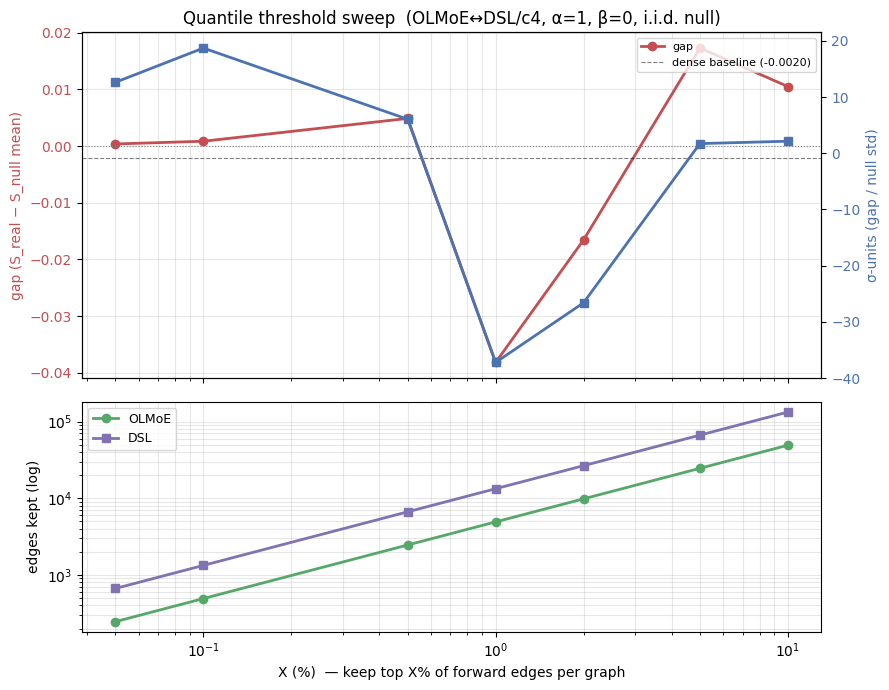

In [10]:
# === Quantile-based threshold sweep (α=1, β=0, OLMoE↔DSL/c4, i.i.d. null) ===
#
# Fraction-of-max didn't reveal structural signal because per-graph
# distribution SHAPES differ -- the same θ_f gave wildly mismatched
# sparsities (OLMoE 19k vs DSL 6.9k edges at θ_f=0.05). This cell uses a
# quantile-based threshold instead: at each sweep point X we keep the top
# X% of forward edges PER GRAPH. By construction this matches sparsity
# proportionally across the two graphs. Tests whether routing topology
# carries cross-model signal when sparsity is matched.
import time 

def quantile_threshold(dag, top_frac):
    """Return θ_abs such that keeping edges with |W| > θ_abs keeps
    approximately the top `top_frac` of forward edges by magnitude.
    E.g. top_frac=0.01 → keep top 1%."""
    W = (dag["P_add"] + dag["P_rem"]).abs()
    L = W.shape[0]
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    forward_vals = W[fwd].numpy()
    return float(np.quantile(forward_vals, 1.0 - top_frac))


X_SWEEP = [0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
N_SEEDS_QUANT = 5

print(f"=== Quantile threshold sweep ({len(X_SWEEP)} fractions × {N_SEEDS_QUANT} seeds) ===")
print(f"  At each X, keep top X% of forward edges per graph (per-graph quantile).")

results_quant = {}
t_total = time.time()
for X in X_SWEEP:
    theta_o = quantile_threshold(dags[("olmoe", "c4")], X)
    theta_d = quantile_threshold(dags[("deepseek-v2-lite", "c4")], X)
    n_o = count_edges_above(dags[("olmoe", "c4")], theta_o)
    n_d = count_edges_above(dags[("deepseek-v2-lite", "c4")], theta_d)
    print(f"\n  --- X={X*100:.2f}%  (OLMoE θ_abs={theta_o:.4f} → {n_o:,} edges;  "
          f"DSL θ_abs={theta_d:.4f} → {n_d:,} edges) ---", flush=True)
    t0 = time.time()
    t_o = mask_triple_by_class(
        build_triple(dags[("olmoe", "c4")], classifications["olmoe"],
                     beta=0.0, edge_threshold=theta_o),
        SPECIAL_IDX, MASK_THRESH)
    t_d = mask_triple_by_class(
        build_triple(dags[("deepseek-v2-lite", "c4")], classifications["deepseek-v2-lite"],
                     beta=0.0, edge_threshold=theta_d),
        SPECIAL_IDX, MASK_THRESH)
    s_real, _ = fgw_similarity(t_o, t_d, alpha=1.0, n_init=5)

    nulls = []
    for seed in range(N_SEEDS_QUANT):
        dag_iid = randomise_dag_iid(dags[("deepseek-v2-lite", "c4")], rng_seed=seed + 5000)
        theta_d_null = quantile_threshold(dag_iid, X)  # per-graph quantile for null too
        t_n = mask_triple_by_class(
            build_triple(dag_iid, classifications["deepseek-v2-lite"],
                         beta=0.0, edge_threshold=theta_d_null),
            SPECIAL_IDX, MASK_THRESH)
        s, _ = fgw_similarity(t_o, t_n, alpha=1.0, n_init=5)
        nulls.append(s)
    nulls = np.array(nulls)
    mean_null, std_null = float(nulls.mean()), float(nulls.std(ddof=1))
    gap = s_real - mean_null
    z = gap / std_null if std_null > 1e-12 else float("inf")
    results_quant[X] = {
        "real": s_real, "mean": mean_null, "std": std_null, "gap": gap, "z": z,
        "edges_o": n_o, "edges_d": n_d,
        "theta_o": theta_o, "theta_d": theta_d,
    }
    print(f"    S_real={s_real:.4f}  null={mean_null:.4f} ± {std_null:.4f}  "
          f"gap={gap:+.4f}  ({z:+.2f}σ)  [{time.time()-t0:.0f}s]", flush=True)

print(f"\n=== Total sweep compute: {(time.time()-t_total)/60:.1f} min ===")

# --- Summary table (include dense baseline) ---
print(f"\n=== Summary (OLMoE↔DSL/c4, α=1, β=0, i.i.d. null, per-graph quantile) ===")
print(f"  {'X':>7s}  {'θ_O':>8s} {'θ_D':>8s}  {'edges_O':>9s} {'edges_D':>9s}  "
      f"{'S_real':>7s}  {'null mean ± std':>18s}  {'gap':>9s}  {'σ-units':>9s}")
print(f"  {'-'*7}  {'-'*8} {'-'*8}  {'-'*9} {'-'*9}  {'-'*7}  {'-'*18}  {'-'*9}  {'-'*9}")
edges_o_dense = count_edges_above(dags[("olmoe", "c4")], 0.0)
edges_d_dense = count_edges_above(dags[("deepseek-v2-lite", "c4")], 0.0)
print(f"  {'dense':>7s}  {0.0:>8.4f} {0.0:>8.4f}  {edges_o_dense:>9,d} {edges_d_dense:>9,d}  "
      f"{S_dense:>7.4f}  {m_d:>9.4f} ± {s_d:.4f}  "
      f"{S_dense - m_d:>+9.4f}  {(S_dense - m_d)/max(s_d, 1e-12):>+9.2f}")
for X in X_SWEEP:
    r = results_quant[X]
    print(f"  {X*100:>6.2f}%  {r['theta_o']:>8.4f} {r['theta_d']:>8.4f}  "
          f"{r['edges_o']:>9,d} {r['edges_d']:>9,d}  "
          f"{r['real']:>7.4f}  {r['mean']:>9.4f} ± {r['std']:.4f}  "
          f"{r['gap']:>+9.4f}  {r['z']:>+9.2f}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})

xs = np.array([X * 100 for X in X_SWEEP])
gaps = np.array([results_quant[X]["gap"] for X in X_SWEEP])
zs = np.array([results_quant[X]["z"] for X in X_SWEEP])

color_gap, color_z = "#C44E52", "#4C72B0"
ax1.semilogx(xs, gaps, marker="o", color=color_gap, linewidth=2, label="gap")
ax1.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax1.axhline(S_dense - m_d, color="black", linestyle="--", linewidth=0.8, alpha=0.5,
            label=f"dense baseline ({S_dense - m_d:+.4f})")
ax1.set_ylabel("gap (S_real − S_null mean)", color=color_gap)
ax1.tick_params(axis="y", labelcolor=color_gap)
ax1.grid(alpha=0.3, which="both")
ax1.legend(loc="upper right", fontsize=8)
ax1b = ax1.twinx()
ax1b.semilogx(xs, zs, marker="s", color=color_z, linewidth=2)
ax1b.set_ylabel("σ-units (gap / null std)", color=color_z)
ax1b.tick_params(axis="y", labelcolor=color_z)
ax1.set_title(f"Quantile threshold sweep  (OLMoE↔DSL/c4, α=1, β=0, i.i.d. null)")

edges_o_arr = np.array([results_quant[X]["edges_o"] for X in X_SWEEP])
edges_d_arr = np.array([results_quant[X]["edges_d"] for X in X_SWEEP])
ax2.semilogx(xs, edges_o_arr, marker="o", color="#55A868", linewidth=2, label="OLMoE")
ax2.semilogx(xs, edges_d_arr, marker="s", color="#8172B2", linewidth=2, label="DSL")
ax2.set_yscale("log")
ax2.set_xlabel("X (%)  — keep top X% of forward edges per graph")
ax2.set_ylabel("edges kept (log)")
ax2.grid(alpha=0.3, which="both")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout(); plt.show()
